# Linear Attention ViT Pipeline for Particle Collision Images

**GSoC ML4SCI Project** -- Project-Requirement Aligned Notebook

This notebook is aligned to the required task flow:
1. **Pretrain Linear Attention ViT encoder** on unlabeled detector images using three SSL methods: **SimMIM, MAE, MAEv2**
2. **Save separate pretrained encoder weights** for each SSL method
3. **Fine-tune Linear Attention ViT** (low learning rate) from each pretrained encoder on labeled data
4. **Train the same Linear Attention ViT from scratch** under matched settings
5. **Compare SimMIM/MAE/MAEv2-pretrained vs scratch** using classification + regression metrics

Primary architecture for the required path:
- **Linear Attention ViT** -- ReLU/positive-kernel linear attention, O(N*d^2) in tokens

Secondary baselines (optional for broader benchmarking):
- Standard ViT, L2ViT, XCiT ViT

Architecture diagrams: `../images/`

---

### Changelog (Alignment + Stability)

| Change | Why |
|--------|-----|
| Requirement-first narrative (pretrain -> fine-tune -> scratch) | Matches project/mentor task description exactly |
| Linear-attention modular SSL classes in Section 5 | Keeps architecture and SSL implementation consistent |
| NaN-safe attention/loss guards | Prevents unstable pretraining loss explosions in notebook runs |
| Backward-compatible class aliases (`*Pretrainer`) | Keeps existing training/eval code unchanged |
| Existing loops/data/eval left untouched | Preserves reproducibility of your original workflow |

**How to run:**
- **Quick sanity test:** Set `RUN_MODE = "debug"` in Section 1, then Run All.
- **Full required experiment:** Set `RUN_MODE = "full"`, run Section 9 -> Section 10 -> Section 11.
- **Reporting:** Use benchmark and summary sections to compare SimMIM/MAE/MAEv2-pretrained vs scratch and baselines.

## Section 1: Configuration

In [1]:

import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

RUN_MODE = "full"

STRICT_DETERMINISM = False


IMG_SIZE = 64                                  
PATCH_SIZE = 8                                      
IN_CHANS = 8                                                       
EMBED_DIM = 256                                         
DEPTH = 10                                           
NUM_HEADS = 8                                     
MLP_RATIO = 4.0                              
DROPOUT = 0.1                               

BATCH_SIZE = 32
EPOCHS = 35
LR = 3e-4
WEIGHT_DECAY = 1e-4
TRAIN_FRAC = 0.80                             
SEED = 42
LAMBDA_REG = 0.2                                                                            
REGRESSION_LAMBDA = LAMBDA_REG                         
GRAD_CLIP_NORM = 1.0                                   

USE_HUBER_LOSS = True                                               

USE_AMP = False                                                                         
USE_EMA = False                                                      

ES_PATIENCE = 7                                                      

TWO_PHASE_TRAINING = True
PHASE_A_EPOCHS = 7                                          
PHASE_A_LAMBDA = 0.0                                      

LOG_EVERY_N_BATCHES = 50                                                  

PRETRAIN_EPOCHS = 20
MASK_RATIO = 0.50
LR_PRETRAIN = 1e-3

DATA_DIR = Path(r"C:\Users\Rahul\Desktop\AA Gsoc'26\data")
UNLABELED_FILE = DATA_DIR / "Dataset_Specific_Unlabelled.h5"
LABELED_FILE = DATA_DIR / "Dataset_Specific_labelled_full_only_for_2i.h5"

NUM_CLASSES = 2                                                

DL_NUM_WORKERS = 0
DL_PIN_MEMORY = False

MULTI_SEEDS = [42, 52, 62]


def get_device() -> torch.device:
    """Auto-detect the best available compute device."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
print(f"Using device: {DEVICE}", flush=True)
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}", flush=True)
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB", flush=True)



def seed_everything(seed: int = 42) -> None:
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if STRICT_DETERMINISM:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        torch.use_deterministic_algorithms(False)


seed_everything(SEED)
print(f"Seeds set to {SEED} | STRICT_DETERMINISM={STRICT_DETERMINISM}", flush=True)
print(f"RUN_MODE={RUN_MODE} | EPOCHS={EPOCHS} | PRETRAIN_EPOCHS={PRETRAIN_EPOCHS}", flush=True)
print(f"BATCH_SIZE={BATCH_SIZE} | LR={LR} | WEIGHT_DECAY={WEIGHT_DECAY}", flush=True)
print(f"LAMBDA_REG={LAMBDA_REG} | USE_AMP={USE_AMP} | USE_EMA={USE_EMA}", flush=True)
print(f"PyTorch version: {torch.__version__}", flush=True)



Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.4 GB
Seeds set to 42 | STRICT_DETERMINISM=False
RUN_MODE=full | EPOCHS=35 | PRETRAIN_EPOCHS=20
BATCH_SIZE=32 | LR=0.0003 | WEIGHT_DECAY=0.0001
LAMBDA_REG=0.2 | USE_AMP=False | USE_EMA=False
PyTorch version: 2.3.0+cu121


## Section 2: Dataset Loading

In [2]:

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset


def inspect_hdf5(filepath: str) -> None:
    """Print HDF5 structure, shapes, dtypes, and sample unique values for 1D datasets."""
    print(f"\n=== HDF5 File: {filepath} ===")
    with h5py.File(filepath, "r") as f:
        def _print_tree(name, obj):
            indent = "  " * name.count("/")
            if hasattr(obj, "shape"):
                msg = f"{indent}{name}: shape={obj.shape}, dtype={obj.dtype}"
                if len(obj.shape) == 1 and obj.shape[0] > 0:
                    sample = np.asarray(obj[: min(50, obj.shape[0])]).reshape(-1)
                    msg += f", sample_unique={np.unique(sample)}"
                print(msg)
            else:
                print(f"{indent}{name}/")
        f.visititems(_print_tree)


class LazyHDF5Dataset(Dataset):
    """
    Lazy-loading HDF5 dataset for particle collision images.
    Requires valid keys for labeled data (mass + label).
    """

    def __init__(
        self,
        filepath,
        labeled: bool = True,
        transform=None,
        img_key: str = None,
        mass_key: str = None,
        label_key: str = None,
    ):
        self.filepath = str(filepath)
        self.labeled = labeled
        self.transform = transform
        self._file = None               

        with h5py.File(self.filepath, "r") as f:
            keys = list(f.keys())

            if img_key is not None:
                if img_key not in keys:
                    raise ValueError(f"img_key='{img_key}' not found. Available keys: {keys}")
                self.img_key = img_key
            else:
                preferred_img = ["jet", "X", "images", "image", "data", "X_jets", "jet_images", "jets"]
                self.img_key = None
                for k in preferred_img:
                    if k in keys and hasattr(f[k], "shape") and len(f[k].shape) >= 3:
                        self.img_key = k
                        break
                if self.img_key is None:
                    for k in keys:
                        obj = f[k]
                        if hasattr(obj, "shape") and len(obj.shape) >= 3 and obj.shape[0] > 1:
                            self.img_key = k
                            break
                if self.img_key is None:
                    raise ValueError(f"No image-like key found in {self.filepath}. Keys={keys}")

            self.length = int(f[self.img_key].shape[0])

            self.mass_key = None
            self.label_key = None

            if self.labeled:
                if mass_key is not None:
                    if mass_key not in keys:
                        raise ValueError(f"mass_key='{mass_key}' not found. Available keys: {keys}")
                    self.mass_key = mass_key
                else:
                    for k in ["m", "mass", "m0", "y_mass", "target_mass"]:
                        if k in keys and len(f[k].shape) == 1 and f[k].shape[0] == self.length:
                            self.mass_key = k
                            break
                    if self.mass_key is None:
                        raise ValueError(
                            f"Could not infer mass_key. Please pass it explicitly. Available keys: {keys}"
                        )

                if label_key is not None:
                    if label_key not in keys:
                        raise ValueError(f"label_key='{label_key}' not found. Available keys: {keys}")
                    self.label_key = label_key
                else:
                    for k in ["label", "labels", "y", "cls", "class", "target", "pid"]:
                        if k in keys and len(f[k].shape) == 1 and f[k].shape[0] == self.length:
                            self.label_key = k
                            break
                    if self.label_key is None:
                        for k in keys:
                            if k == self.mass_key:
                                continue
                            obj = f[k]
                            if hasattr(obj, "shape") and len(obj.shape) == 1 and obj.shape[0] == self.length:
                                if np.issubdtype(obj.dtype, np.integer):
                                    self.label_key = k
                                    break

                    if self.label_key is None:
                        raise ValueError(
                            f"Could not infer label_key. Please pass it explicitly. Available keys: {keys}"
                        )

            self.pt_key = None
            for k in ["pT", "pt", "PT", "transverse_momentum"]:
                if k in keys and hasattr(f[k], "shape") and f[k].shape[0] == self.length:
                    self.pt_key = k
                    break

        print(f"[LazyHDF5Dataset] file={self.filepath}")
        print(f"  img_key={self.img_key}")
        if self.labeled:
            print(f"  mass_key={self.mass_key}, label_key={self.label_key}, pt_key={self.pt_key}")

    def _get_file(self):
        if self._file is None or not self._file.id.valid:
            self._file = h5py.File(self.filepath, "r")
        return self._file

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        f = self._get_file()

        img = np.array(f[self.img_key][idx], dtype=np.float32)
        img = torch.from_numpy(img)

        if img.ndim == 2:
            img = img.unsqueeze(0)           
        elif img.ndim == 3:
            if img.shape[-1] <= 16 and img.shape[0] > 16 and img.shape[1] > 16:
                img = img.permute(2, 0, 1)

        if self.transform is not None:
            img = self.transform(img)

        if self.labeled:
            mass  = float(np.array(f[self.mass_key][idx]).squeeze())
            label = int(np.array(f[self.label_key][idx]).squeeze())
            pt    = float(np.array(f[self.pt_key][idx]).squeeze()) if self.pt_key else 0.0
            return (
                img,
                torch.tensor(mass,  dtype=torch.float32),
                torch.tensor(label, dtype=torch.long),
                torch.tensor(pt,    dtype=torch.float32),
            )
        else:
            return (img,)

    def __del__(self):
        if self._file is not None and self._file.id.valid:
            self._file.close()



print("\n--- Loading Datasets (HDF5 only) ---")

if not LABELED_FILE.exists():
    raise FileNotFoundError(f"Labeled HDF5 file not found: {LABELED_FILE}")
if not UNLABELED_FILE.exists():
    raise FileNotFoundError(f"Unlabeled HDF5 file not found: {UNLABELED_FILE}")

print(f"Found labeled file: {LABELED_FILE}")
inspect_hdf5(str(LABELED_FILE))

print(f"\nFound unlabeled file: {UNLABELED_FILE}")
inspect_hdf5(str(UNLABELED_FILE))

LABELED_IMG_KEY = "jet"
LABELED_MASS_KEY = "m"
LABELED_LABEL_KEY = "Y"
UNLABELED_IMG_KEY = "jet"

raw_dataset = LazyHDF5Dataset(
    LABELED_FILE,
    labeled=True,
    img_key=LABELED_IMG_KEY,
    mass_key=LABELED_MASS_KEY,
    label_key=LABELED_LABEL_KEY,
)
unlabeled_dataset_raw = LazyHDF5Dataset(
    UNLABELED_FILE,
    labeled=False,
    img_key=UNLABELED_IMG_KEY,
)

print(f"\nLabeled dataset size: {len(raw_dataset)}")
print(f"Unlabeled dataset size: {len(unlabeled_dataset_raw)}")
print("USING_SYNTHETIC = False")
USING_SYNTHETIC = False


--- Loading Datasets (HDF5 only) ---
Found labeled file: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5

=== HDF5 File: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5 ===
Y: shape=(10000, 1), dtype=float32
jet: shape=(10000, 125, 125, 8), dtype=float32
m: shape=(10000, 1), dtype=float32
pT: shape=(10000, 1), dtype=float32

Found unlabeled file: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5

=== HDF5 File: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5 ===
jet: shape=(60000, 125, 125, 8), dtype=float32
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5
  img_key=jet
  mass_key=m, label_key=Y, pt_key=pT
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5
  img_key=jet

Labeled dataset size: 10000
Unlabeled dataset size: 60000
USING_SYNTHETIC = False


## Section 3: Data Preprocessing & Augmentation

Train samples: 8000 | Val samples: 2000
Label distribution (full):  Counter({0: 5122, 1: 4878})
Label distribution (train): Counter({0: 4107, 1: 3893})
Label distribution (val):   Counter({0: 1015, 1: 985})
Log-mass normalization: log_mean=4.8930, log_std=0.3718
pT normalization: mean=520.6005, std=105.7265
USE_PT_FEATURE=True
Train batches: 250 | Val batches: 63

--- Unlabeled samples (log-compressed, ch 0) ---


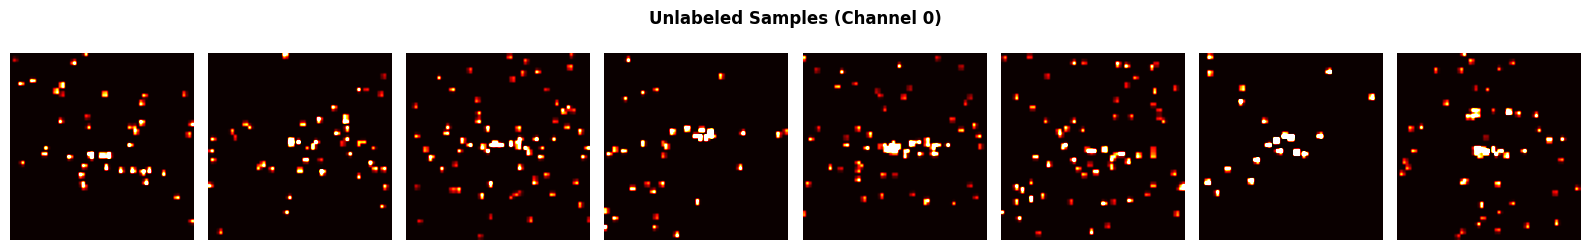


--- Labeled validation samples (log-compressed, ch 0) ---


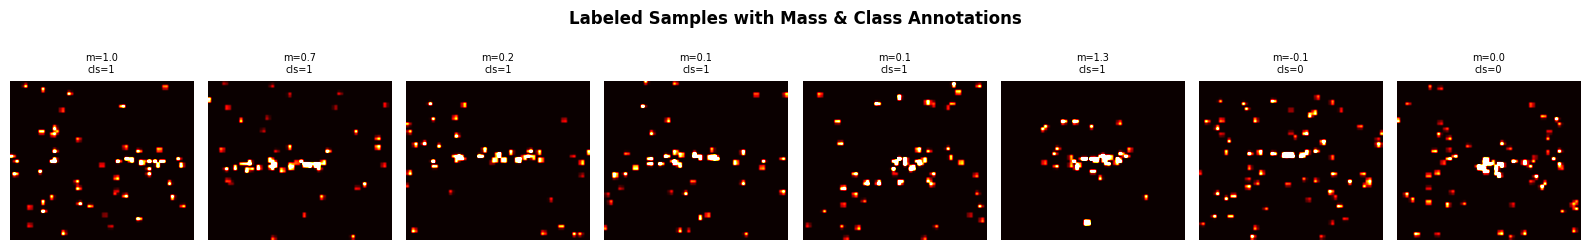

In [3]:

import math
import random
import warnings
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt



class PhysicsPreprocess(nn.Module):
    """Physics-inspired preprocessing for detector images."""

    def __init__(self, img_size: int = 64, in_chans: int = 8, allow_fallback_zeros: bool = True):
        super().__init__()
        self.img_size = int(img_size)
        self.in_chans = int(in_chans)
        self.allow_fallback_zeros = allow_fallback_zeros

        y_coords, x_coords = torch.meshgrid(
            torch.arange(self.img_size, dtype=torch.float32),
            torch.arange(self.img_size, dtype=torch.float32),
            indexing="ij",
        )
        self.register_buffer("x_coords", x_coords, persistent=False)
        self.register_buffer("y_coords", y_coords, persistent=False)

    def _fallback_image(self, device, dtype):
        return torch.zeros((self.in_chans, self.img_size, self.img_size), device=device, dtype=dtype)

    def _to_chw(self, x: torch.Tensor) -> torch.Tensor:
        if not torch.is_tensor(x):
            x = torch.as_tensor(x)
        x = x.float()

        if x.ndim == 0:
            if self.allow_fallback_zeros:
                warnings.warn("PhysicsPreprocess: scalar input encountered; using zeros fallback.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Expected image-like tensor, got scalar: {x}")

        if x.ndim == 1 and x.numel() <= 1:
            if self.allow_fallback_zeros:
                warnings.warn(f"PhysicsPreprocess: tiny 1D input shape={tuple(x.shape)}; using zeros fallback.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Tiny 1D tensor cannot represent image: shape={tuple(x.shape)}")

        if x.ndim == 1:
            n = x.numel()
            if n % self.in_chans == 0:
                hw = n // self.in_chans
                h = int(math.isqrt(hw))
                if h * h == hw:
                    return x.view(self.in_chans, h, h)
            h = int(math.isqrt(n))
            if h * h == n:
                return x.view(1, h, h)
            if self.allow_fallback_zeros:
                warnings.warn(f"PhysicsPreprocess: cannot infer image shape from flattened length={n}; fallback zeros.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Cannot infer image shape from flattened tensor length={n}")

        if x.ndim == 2:
            return x.unsqueeze(0)

        if x.ndim == 3:
            if x.shape[-1] <= 16 and x.shape[0] > 16 and x.shape[1] > 16:
                return x.permute(2, 0, 1)
            return x

        if self.allow_fallback_zeros:
            warnings.warn(f"PhysicsPreprocess: unsupported ndim={x.ndim}, shape={tuple(x.shape)}; fallback zeros.")
            return self._fallback_image(x.device, x.dtype)
        raise ValueError(f"Unsupported input shape: {tuple(x.shape)}")

    def energy_center_align(self, x: torch.Tensor) -> torch.Tensor:
        c, h, w = x.shape

        energy = x.sum(dim=0)
        total_energy = energy.sum()
        if total_energy.abs() < 1e-6:
            return x

        if h == self.img_size and w == self.img_size:
            x_coords = self.x_coords
            y_coords = self.y_coords
        else:
            y_coords, x_coords = torch.meshgrid(
                torch.arange(h, device=x.device, dtype=torch.float32),
                torch.arange(w, device=x.device, dtype=torch.float32),
                indexing="ij",
            )

        cx = (energy * x_coords).sum() / total_energy
        cy = (energy * y_coords).sum() / total_energy

        shift_x = int((w // 2) - cx.item())
        shift_y = int((h // 2) - cy.item())

        x = torch.roll(x, shifts=(shift_y, shift_x), dims=(1, 2))
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._to_chw(x)

        x = torch.log1p(x.clamp(min=0.0))                                  
        x = torch.where(x < 1e-3, torch.zeros_like(x), x)                    
        x = self.energy_center_align(x)                                        

        if x.shape[-2] != self.img_size or x.shape[-1] != self.img_size:
            x = TF.resize(x, [self.img_size, self.img_size], antialias=True)

        c = x.shape[0]
        if c < self.in_chans:
            repeats = (self.in_chans + c - 1) // c
            x = x.repeat(repeats, 1, 1)[: self.in_chans]
        elif c > self.in_chans:
            x = x[: self.in_chans]

        x = x / (x.sum() + 1e-8)                       

        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True)
        x = (x - mean) / (std + 1e-6)

        return x



class AugmentTransform(nn.Module):
    """Physics-safe data augmentation."""
    def __init__(self, p: float = 0.25, noise_std: float = 0.01):
        super().__init__()
        self.p = float(p)
        self.noise_std = float(noise_std)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if random.random() < self.p:
            x = TF.hflip(x)

        if random.random() < self.p:
            x = x + torch.randn_like(x) * self.noise_std

        if random.random() < self.p:
            x = x * (0.9 + 0.2 * random.random())

        if random.random() < self.p:
            _, h, w = x.shape
            patch_size = random.randint(2, 4)
            y0 = random.randint(0, max(0, h - patch_size))
            x0 = random.randint(0, max(0, w - patch_size))
            x[:, y0:y0 + patch_size, x0:x0 + patch_size] = 0.0

        return x


class TrainTransform(nn.Module):
    def __init__(self, img_size=64, in_chans=8):
        super().__init__()
        self.preprocess = PhysicsPreprocess(img_size=img_size, in_chans=in_chans, allow_fallback_zeros=True)
        self.augment = AugmentTransform()

    def forward(self, x):
        return self.augment(self.preprocess(x))


class ValTransform(nn.Module):
    def __init__(self, img_size=64, in_chans=8):
        super().__init__()
        self.preprocess = PhysicsPreprocess(img_size=img_size, in_chans=in_chans, allow_fallback_zeros=True)

    def forward(self, x):
        return self.preprocess(x)


class TransformedDataset(Dataset):
    """Wraps base dataset + transform on image only. Passes through mass, label, pT."""
    def __init__(self, base_dataset: Dataset, transform=None,
                 mass_mean: float = None, mass_std: float = None,
                 pt_mean: float = None, pt_std: float = None,
                 log_mass: bool = False):
        self.base     = base_dataset
        self.transform = transform
        self.mass_mean = mass_mean
        self.mass_std  = mass_std
        self.pt_mean   = pt_mean
        self.pt_std    = pt_std
        self.log_mass  = log_mass                                               

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        img  = self.transform(item[0]) if self.transform is not None else item[0]

        if len(item) >= 3:
            mass  = torch.as_tensor(item[1]).view(-1)[0].to(torch.float32)
            label = torch.as_tensor(item[2]).view(-1)[0].to(torch.long)
            pt    = torch.as_tensor(item[3]).view(-1)[0].to(torch.float32) if len(item) >= 4 else torch.tensor(0.0)

            if self.log_mass:
                mass = torch.log(mass.clamp(min=1e-3))

            if self.mass_mean is not None and self.mass_std is not None:
                denom = self.mass_std if abs(float(self.mass_std)) > 1e-12 else 1.0
                mass  = (mass - float(self.mass_mean)) / float(denom)

            if self.pt_mean is not None and self.pt_std is not None:
                denom = self.pt_std if abs(float(self.pt_std)) > 1e-12 else 1.0
                pt    = (pt - float(self.pt_mean)) / float(denom)

            return img, mass, label, pt

        return (img,) + item[1:]


def compute_mass_stats(dataset):
    masses = []
    for i in range(len(dataset)):
        item = dataset[i]
        if len(item) >= 2:
            m = torch.as_tensor(item[1]).view(-1)[0].item()
            masses.append(float(m))
    if len(masses) == 0:
        return 0.0, 1.0
    masses = torch.tensor(masses, dtype=torch.float32)
    std = masses.std().item()
    if std < 1e-12:
        std = 1.0
    return masses.mean().item(), std

def compute_pt_stats(dataset):
    """Compute mean and std of pT from dataset for normalization."""
    pts = []
    for i in range(len(dataset)):
        item = dataset[i]
        if len(item) >= 4:
            pts.append(float(torch.as_tensor(item[3]).view(-1)[0].item()))
    if not pts:
        return 0.0, 1.0
    pts = torch.tensor(pts, dtype=torch.float32)
    std = pts.std().item()
    return pts.mean().item(), (std if std > 1e-12 else 1.0)


def get_label_dist(dataset):
    cnt = Counter()
    for i in range(len(dataset)):
        y = dataset[i][2]
        y = int(torch.as_tensor(y).view(-1)[0].item())
        cnt[y] += 1
    return cnt


n_total = len(raw_dataset)
n_train = int(n_total * TRAIN_FRAC)
n_val = n_total - n_train
generator = torch.Generator().manual_seed(SEED)
train_raw, val_raw = random_split(raw_dataset, [n_train, n_val], generator=generator)

print(f"Train samples: {n_train} | Val samples: {n_val}")

dist_all = get_label_dist(raw_dataset)
dist_train = get_label_dist(train_raw)
dist_val = get_label_dist(val_raw)

print("Label distribution (full): ", dist_all)
print("Label distribution (train):", dist_train)
print("Label distribution (val):  ", dist_val)

if len(dist_all) < 2:
    raise RuntimeError(
        "Only one class detected in labeled dataset. Recheck Section 2 label_key (should be 'Y' for your file)."
    )

LOG_MASS = True                                                       

if LOG_MASS:
    import numpy as _np
    _raw_masses = [float(torch.as_tensor(train_raw[i][1]).view(-1)[0]) for i in range(len(train_raw))]
    _log_masses = _np.log(_np.clip(_raw_masses, 1e-3, None))
    MASS_MEAN   = float(_np.mean(_log_masses))
    MASS_STD    = float(_np.std(_log_masses))
    print(f"Log-mass normalization: log_mean={MASS_MEAN:.4f}, log_std={MASS_STD:.4f}")
else:
    MASS_MEAN, MASS_STD = compute_mass_stats(train_raw)
    print(f"Mass normalization: mean={MASS_MEAN:.4f}, std={MASS_STD:.4f}")

RAW_MASS_MEAN = MASS_MEAN
RAW_MASS_STD  = MASS_STD

PT_MEAN, PT_STD = compute_pt_stats(train_raw)
print(f"pT normalization: mean={PT_MEAN:.4f}, std={PT_STD:.4f}")
USE_PT_FEATURE  = PT_STD > 1e-6                               
print(f"USE_PT_FEATURE={USE_PT_FEATURE}")

train_dataset = TransformedDataset(
    train_raw, TrainTransform(IMG_SIZE, IN_CHANS),
    mass_mean=MASS_MEAN, mass_std=MASS_STD,
    pt_mean=PT_MEAN,     pt_std=PT_STD,
    log_mass=LOG_MASS,
)
val_dataset = TransformedDataset(
    val_raw, ValTransform(IMG_SIZE, IN_CHANS),
    mass_mean=MASS_MEAN, mass_std=MASS_STD,
    pt_mean=PT_MEAN,     pt_std=PT_STD,
    log_mass=LOG_MASS,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=DL_NUM_WORKERS,
    pin_memory=DL_PIN_MEMORY,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=DL_NUM_WORKERS,
    pin_memory=DL_PIN_MEMORY,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


def plot_sample_images_raw(dataset: Dataset, n: int = 8, title: str = "Sample Images") -> None:
    n = min(n, len(dataset))
    if n == 0:
        print("Dataset is empty.")
        return

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    if n == 1:
        axes = [axes]

    shown, i = 0, 0
    while shown < n and i < len(dataset):
        ax = axes[shown]
        try:
            item = dataset[i]
            img = item[0]
            if img.ndim == 3:
                img = img[0]
            arr = img.detach().cpu().numpy()

            vmin = np.percentile(arr, 1)
            vmax = np.percentile(arr, 99)
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
                vmin, vmax = None, None

            ax.imshow(arr, cmap="hot", aspect="auto", vmin=vmin, vmax=vmax)
            ax.axis("off")

            if len(item) >= 3:
                mass = float(torch.as_tensor(item[1]).view(-1)[0].item())
                label = int(torch.as_tensor(item[2]).view(-1)[0].item())
                ax.set_title(f"m={mass:.1f}\ncls={label}", fontsize=7)

            shown += 1
        except Exception:
            pass
        i += 1

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("\n--- Unlabeled samples (log-compressed, ch 0) ---")
unlabeled_vis = TransformedDataset(unlabeled_dataset_raw, ValTransform(IMG_SIZE, IN_CHANS))
plot_sample_images_raw(unlabeled_vis, n=min(8, len(unlabeled_vis)), title="Unlabeled Samples (Channel 0)")

print("\n--- Labeled validation samples (log-compressed, ch 0) ---")
plot_sample_images_raw(val_dataset, n=min(8, len(val_dataset)), title="Labeled Samples with Mass & Class Annotations")

## Section 4: Model Architectures

Four core architectures for benchmarking:
- **StandardViT**: quadratic self-attention baseline O(N^2*d)
- **LinearAttentionViT**: ReLU kernel linear attention O(N*d^2)
- **L2ViT**: Linear Global Attention + Local Window Attention (hybrid)
- **XCiTViT**: Cross-Covariance Attention O(N*d^2) (El-Nouby et al.)

Modular design allows swapping attention mechanisms easily.

In [4]:

import math
from functools import partial

import torch.nn.functional as F



class DropPath(nn.Module):
    """Stochastic Depth (Drop Path) regularization.
    Reference: Huang et al., 2016."""

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob


class PatchEmbed(nn.Module):
    """Image-to-patch embedding using Conv2D.
    Input: B x C x H x W -> Output: B x N x D
    Includes positional encoding via learnable embeddings."""

    def __init__(self, img_size=64, patch_size=8, in_chans=8, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)                                            
        x = x.flatten(2).transpose(1, 2)                     
        return x


class MLP(nn.Module):
    """Two-layer FFN with GELU activation and dropout."""

    def __init__(self, in_features: int, hidden_features: int = None, dropout: float = 0.0):
        super().__init__()
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


def _make_cls_head(in_dim: int, out_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """Two-layer classification head."""
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, out_dim),
    )


def _make_reg_head(in_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """Deeper 3-layer regression head for improved mass prediction."""
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, in_dim // 4),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 4, 1),
)

class RegressionHead(nn.Module):
    """
    Regression head for jet mass prediction.
    - Input: [CLS_token | mean_token | pT_normalized]  →  (embed_dim*2 + 1)
    - Kaiming init eliminates bad random start
    - pT is a physics prior strongly correlated with jet mass
    """
    def __init__(self, embed_dim: int, dropout: float = 0.1, use_pt: bool = True):
        super().__init__()
        self.use_pt  = use_pt
        in_dim       = embed_dim * 2 + (1 if use_pt else 0)
        self.net = nn.Sequential(
            nn.Linear(in_dim,          embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim,       embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2,  embed_dim // 4),
            nn.GELU(),
            nn.Linear(embed_dim // 4,  1),
        )
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
        nn.init.trunc_normal_(self.net[-1].weight, std=0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, features: torch.Tensor, pt: torch.Tensor = None) -> torch.Tensor:
        if self.use_pt and pt is not None:
            pt_feat = pt.view(-1, 1)
            x = torch.cat([features, pt_feat], dim=1)
        else:
            x = features
        return self.net(x)



class UnifiedLinearAttention(nn.Module):
    """
    Single linear attention class shared by SSL pretrainer and fine-tune model.
    Kernel: phi(x) = ELU(x) + 1  — positive, stable, no dead neurons.
    Complexity: O(N * d^2).
    """
    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0, eps: float = 1e-6):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.eps       = eps
        self.qkv       = nn.Linear(dim, dim * 3, bias=False)
        self.proj      = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.elu(q) + 1.0                                             
        k = F.elu(k) + 1.0

        kv      = k.transpose(-2, -1) @ v                              
        out_num = q @ kv                                                
        k_sum   = k.sum(dim=-2, keepdim=True)
        out_den = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=self.eps)
        out     = out_num / out_den
        out     = torch.nan_to_num(out, nan=0.0, posinf=1e4, neginf=-1e4)

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


def mixup_batch(imgs, masses, labels, alpha=0.4, pts=None):
    if alpha <= 0:
        return imgs, masses, labels, labels, 1.0, pts
    lam  = float(np.random.beta(alpha, alpha))
    B    = imgs.size(0)
    perm = torch.randperm(B, device=imgs.device)
    mixed_imgs   = lam * imgs   + (1 - lam) * imgs[perm]
    mixed_masses = lam * masses + (1 - lam) * masses[perm]
    mixed_pts    = (lam * pts + (1 - lam) * pts[perm]) if pts is not None else None
    return mixed_imgs, mixed_masses, labels, labels[perm], lam, mixed_pts


def physics_cutmix_batch(imgs, masses, labels, alpha=0.4, pts=None):
    if alpha <= 0:
        return imgs, masses, labels, labels, 1.0, pts
    lam  = float(np.random.beta(alpha, alpha))
    B, C, H, W = imgs.shape
    perm = torch.randperm(B, device=imgs.device)
    cut_ratio = math.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
    mixed_imgs = imgs.clone()
    mixed_imgs[:, :, y1:y2, x1:x2] = imgs[perm, :, y1:y2, x1:x2]
    lam = 1.0 - (x2 - x1) * (y2 - y1) / (H * W)
    mixed_masses = lam * masses + (1 - lam) * masses[perm]
    mixed_pts    = (lam * pts + (1 - lam) * pts[perm]) if pts is not None else None
    return mixed_imgs, mixed_masses, labels, labels[perm], lam, mixed_pts


def mixup_cross_entropy(logits, labels_a, labels_b, lam):
    """Cross-entropy loss for mixed labels."""
    return lam * F.cross_entropy(logits, labels_a) +\
           (1 - lam) * F.cross_entropy(logits, labels_b)



class MultiHeadSelfAttention(nn.Module):
    """Standard multi-head self-attention: Softmax(QK^T / sqrt(d)) V. O(N^2*d)."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))


class ViTBlock(nn.Module):
    """Pre-norm ViT block: x = x + Attn(LN(x)); x = x + FFN(LN(x))."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class StandardViT(nn.Module):
    """Standard Vision Transformer with quadratic self-attention.
    Reference: Dosovitskiy et al., ICLR 2021."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout, use_pt=True)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = x + self.pos_embed                                         
        cls = self.cls_token.expand(B, -1, -1)                         
        x = torch.cat([cls, x], dim=1)                                   
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                                               

    def forward(self, x: torch.Tensor, pt: torch.Tensor = None):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                                     
        mean_token = tokens[:, 1:].mean(dim=1)                       
        features = torch.cat([cls_token, mean_token], dim=1)          
        return self.regression_head(features, pt), self.classification_head(cls_token)



class LinearAttention(nn.Module):
    """Linear Attention using ReLU kernel feature maps.
    phi(Q) = ReLU(Q), phi(K) = ReLU(K)
    Attention: phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
    Complexity: O(N * d^2) -- linear in number of tokens."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.relu(q)
        k = F.relu(k)

        kv = k.transpose(-2, -1) @ v                               
        qkv_out = q @ kv                                           

        k_sum = k.sum(dim=-2, keepdim=True)                         
        normalizer = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-6)
        out = qkv_out / normalizer

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


class LinearViTBlock(nn.Module):
    """Pre-norm transformer block using Linear Attention."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = UnifiedLinearAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LinearAttentionViT(nn.Module):
    """Linear Attention ViT using ReLU kernel feature maps.
    phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
    Complexity: O(N * d^2) per layer -- linear in tokens."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            LinearViTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout, use_pt=True)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = x + self.pos_embed                                         
        cls = self.cls_token.expand(B, -1, -1)                         
        x = torch.cat([cls, x], dim=1)                                   
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                                               

    def forward(self, x: torch.Tensor, pt: torch.Tensor = None):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                                     
        mean_token = tokens[:, 1:].mean(dim=1)                       
        features = torch.cat([cls_token, mean_token], dim=1)          
        return self.regression_head(features, pt), self.classification_head(cls_token)



class LocalConcentrationModule(nn.Module):
    """Local Concentration Module (LCM) from L2ViT.
    Re-focuses dispersive linear-attention maps via depth-wise convolutions."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        x2d = self.act(self.bn(self.conv1(x2d)))
        x2d = self.conv2(x2d)
        return x2d.reshape(B, D, N).transpose(1, 2)


class LinearGlobalAttention(nn.Module):
    """Linear Global Attention (LGA) from L2ViT.
    Uses ReLU kernel: phi(Q) = ReLU(Q), phi(K) = ReLU(K).
    Complexity: O(N * C^2) -- linear in tokens."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = nn.Parameter(torch.ones(1) * math.sqrt(self.head_dim))
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.relu(q)
        k = F.relu(k)

        kv = k.transpose(-2, -1) @ v * self.scale
        qkv_out = q @ kv
        k_sum = k.sum(dim=-2, keepdim=True)
        normalizer = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-2)
        out = qkv_out / normalizer

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


class LocalWindowAttention(nn.Module):
    """Local Window Attention (LWA) from L2ViT.
    Standard self-attention within non-overlapping windows."""

    def __init__(self, dim: int, num_heads: int = 8, window_size: int = 4, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.window_size = window_size
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        H = W = int(math.sqrt(N))
        ws = self.window_size

        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        x2d = x.transpose(1, 2).reshape(B, D, H, W)
        if pad_h > 0 or pad_w > 0:
            x2d = F.pad(x2d, (0, pad_w, 0, pad_h))
        Hp, Wp = x2d.shape[2], x2d.shape[3]

        nH, nW = Hp // ws, Wp // ws
        x_win = x2d.reshape(B, D, nH, ws, nW, ws)
        x_win = x_win.permute(0, 2, 4, 3, 5, 1).reshape(B * nH * nW, ws * ws, D)

        qkv = self.qkv(x_win).reshape(-1, ws * ws, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        out = (attn @ v).transpose(1, 2).reshape(B * nH * nW, ws * ws, D)

        out = out.reshape(B, nH, nW, ws, ws, D)
        out = out.permute(0, 5, 1, 3, 2, 4).reshape(B, D, Hp, Wp)
        if pad_h > 0 or pad_w > 0:
            out = out[:, :, :H, :W]
        out = out.reshape(B, D, N).transpose(1, 2)
        return self.proj_drop(self.proj(out))


class ConditionalPositionalEncoding(nn.Module):
    """Conditional Positional Encoding via depth-wise convolution."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        return x + self.conv(x2d).reshape(B, D, N).transpose(1, 2)


class LGABlock(nn.Module):
    """L2ViT block: CPE + Linear Global Attention + LCM + FFN."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout, drop_path, n_patches_side):
        super().__init__()
        self.cpe = ConditionalPositionalEncoding(dim, n_patches_side)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearGlobalAttention(dim, num_heads, dropout)
        self.norm_lcm = nn.LayerNorm(dim)
        self.lcm = LocalConcentrationModule(dim, n_patches_side)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cls, patches = x[:, :1], x[:, 1:]
        patches = self.cpe(patches)                                                       
        x = torch.cat([cls, patches], dim=1)

        x = x + self.drop_path(self.attn(self.norm1(x)))                                

        cls, patches = x[:, :1], x[:, 1:]
        patches = patches + self.drop_path(self.lcm(self.norm_lcm(patches)))                       
        x = torch.cat([cls, patches], dim=1)

        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LWABlock(nn.Module):
    """L2ViT block: CPE + Local Window Attention + FFN."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout, drop_path, n_patches_side, window_size=4):
        super().__init__()
        self.cpe = ConditionalPositionalEncoding(dim, n_patches_side)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LocalWindowAttention(dim, num_heads, window_size, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cls, patches = x[:, :1], x[:, 1:]
        patches = self.cpe(patches)                                               
        x = torch.cat([cls, patches], dim=1)

        cls, patches = x[:, :1], x[:, 1:]
        patches = patches + self.drop_path(self.attn(self.norm1(patches)))
        x = torch.cat([cls, patches], dim=1)

        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class L2ViT(nn.Module):
    """L2ViT: Linear Global Attention + Local Window Attention hybrid.
    Alternating pattern: LWA -> LGA -> LWA -> LGA ...
    Reference: Zheng, 'The Linear Attention Resurrection in Vision Transformer', 2025."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
        window_size=4,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        n_side = img_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList()
        for i in range(depth):
            if i % 2 == 0:
                self.blocks.append(
                    LWABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side, window_size)
                )
            else:
                self.blocks.append(
                    LGABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side)
                )
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout, use_pt=True)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, (nn.LayerNorm, nn.BatchNorm2d)):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)                                         
        B = x.shape[0]
        x = x + self.pos_embed                                                              
        cls = self.cls_token.expand(B, -1, -1)                          
        x = torch.cat([cls, x], dim=1)                                                        
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)                                                    
        return self.norm(x)                                                

    def forward(self, x: torch.Tensor, pt: torch.Tensor = None):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                                     
        mean_token = tokens[:, 1:].mean(dim=1)                       
        features = torch.cat([cls_token, mean_token], dim=1)          
        return self.regression_head(features, pt), self.classification_head(cls_token)



class CrossCovarianceAttention(nn.Module):
    """Cross-Covariance Attention (XCA) from XCiT.
    Q^T K -> d x d channel attention matrix.
    Complexity: O(N * d^2) -- linear in tokens.
    Reference: El-Nouby et al., NeurIPS 2021."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.normalize(q, dim=-2)
        k = F.normalize(k, dim=-2)

        attn = (q.transpose(-2, -1) @ k) * self.temperature
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        x = (v @ attn).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))


class LocalPatchInteraction(nn.Module):
    """Local Patch Interaction (LPI) from XCiT.
    Two depth-wise 3x3 convolutions for local patch correlations."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        x2d = self.act(self.bn(self.conv1(x2d)))
        x2d = self.conv2(x2d)
        return x2d.reshape(B, D, N).transpose(1, 2)


class LayerScale(nn.Module):
    """CaiT-style learnable per-channel scaling (init to 1e-4)."""
    def __init__(self, dim: int, init_values: float = 1e-4):
        super().__init__()
        self.gamma = nn.Parameter(init_values * torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.gamma * x


class XCiTBlock(nn.Module):
    """XCiT block: XCA + LPI + FFN with LayerScale."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout,
                 drop_path, n_patches_side, init_values=1e-4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = CrossCovarianceAttention(dim, num_heads, dropout)
        self.norm_lpi = nn.LayerNorm(dim)
        self.lpi = LocalPatchInteraction(dim, n_patches_side)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.ls1 = LayerScale(dim, init_values)
        self.ls2 = LayerScale(dim, init_values)
        self.ls3 = LayerScale(dim, init_values)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.ls1(self.attn(self.norm1(x))))

        cls, patches = x[:, :1], x[:, 1:]
        patches = patches + self.drop_path(self.ls2(self.lpi(self.norm_lpi(patches))))
        x = torch.cat([cls, patches], dim=1)

        x = x + self.drop_path(self.ls3(self.mlp(self.norm2(x))))
        return x


class XCiTViT(nn.Module):
    """XCiT Vision Transformer using Cross-Covariance Attention.
    Reference: El-Nouby et al., NeurIPS 2021."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        n_side = img_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            XCiTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side)
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout, use_pt=True)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = self.pos_drop(x + self.pos_embed)                          
        cls = self.cls_token.expand(B, -1, -1)                          
        x = torch.cat([cls, x], dim=1)                                                        
        for blk in self.blocks:
            x = blk(x)                                                    
        return self.norm(x)                                                

    def forward(self, x: torch.Tensor, pt: torch.Tensor = None):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                                     
        mean_token = tokens[:, 1:].mean(dim=1)                       
        features = torch.cat([cls_token, mean_token], dim=1)          
        return self.regression_head(features, pt), self.classification_head(cls_token)



print("=" * 60)
print("Model Architecture Summary")
print("=" * 60)

_dummy    = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE)
_dummy_pt = torch.zeros(2)
for ModelClass in [StandardViT, LinearAttentionViT, L2ViT, XCiTViT]:
    model = ModelClass()
    mass, cls = model(_dummy, _dummy_pt)
    params = model.count_params()
    print(f"\n{ModelClass.__name__}:")
    print(f"  mass_pred shape : {mass.shape}")
    print(f"  class_logits shape: {cls.shape}")
    print(f"  Trainable params: {params:,} ({params/1e6:.2f}M)")
    del model
print("=" * 60)


Model Architecture Summary

StandardViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,244,355 (8.24M)

LinearAttentionViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,244,355 (8.24M)

L2ViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,403,080 (8.40M)

XCiTViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,313,555 (8.31M)


## Section 5: Self-Supervised Pretraining Models

Three masked-image-modeling approaches for representation learning:
- **MAEPretrainer**: Masked Autoencoder with pixel reconstruction
- **MAEv2Pretrainer**: Feature distillation with EMA teacher
- **SimMIMPretrainer**: Simple MIM with L1 pixel loss

In [5]:

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F


class PatchEmbedding(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=IN_CHANS, embed_dim=EMBED_DIM):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.embed_dim = embed_dim
        self.n_side = img_size // patch_size
        self.n_patches = self.n_side * self.n_side
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class LinearSelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0, eps: float = 1e-6):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.eps = eps
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = k.transpose(-2, -1) @ v
        out_num = q @ kv

        k_sum = k.sum(dim=-2, keepdim=True)
        out_den = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=self.eps)
        out = out_num / out_den
        out = torch.nan_to_num(out, nan=0.0, posinf=1e4, neginf=-1e4)

        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        return self.proj_drop(out)


class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0, drop_path: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = UnifiedLinearAttention(dim, num_heads=num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)


class EnergyProxyHead(nn.Module):
    """
    Mass-aware SSL auxiliary head.
    Predicts 4 energy proxy scalars from the mean encoder token — all
    computable from unlabeled jet images without any mass labels:
      1. log(total_energy + 1)   — strongly correlated with jet mass
      2. log(max_energy + 1)     — peak energy deposit
      3. energy_spread (std)     — spatial energy distribution
      4. log(n_active + 1)       — number of active detector cells

    These proxies teach the encoder to be aware of energy scale and
    spatial structure — features directly relevant to mass regression.
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, 4),                   
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(x.mean(dim=1))           


def compute_energy_proxies(imgs: torch.Tensor) -> torch.Tensor:
    """
    Compute 4 physics-motivated energy proxy targets from raw jet images.
    All are computable from unlabeled data (no mass labels needed).

    Args:
        imgs: (B, C, H, W) — preprocessed jet images (log-compressed)
    Returns:
        (B, 4) tensor of normalized proxy targets
    """
    energy = imgs.sum(dim=1)                                                     

    proxy1 = torch.log1p(energy.sum(dim=(1, 2)))                                        
    proxy2 = torch.log1p(energy.flatten(1).max(dim=1).values)                         
    proxy3 = energy.flatten(1).std(dim=1)                                            
    proxy4 = torch.log1p((energy > 0.01).float().sum(dim=(1, 2)))                       

    proxies = torch.stack([proxy1, proxy2, proxy3, proxy4], dim=1)            

    mean = proxies.mean(dim=0, keepdim=True)
    std  = proxies.std(dim=0, keepdim=True).clamp(min=1e-6)
    return (proxies - mean) / std


class LinearAttentionViTEncoder(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
        drop_path_rate: float = 0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        self.n_patches = self.patch_embed.n_patches
        self.n_side = self.patch_embed.n_side
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.encoder_norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        x = self.pos_drop(x + self.pos_embed)
        for blk in self.encoder_blocks:
            x = blk(x)
        return self.encoder_norm(x)


def random_patch_masking(
    x: torch.Tensor,
    mask_ratio: float,
    block_masking: bool = False,
    n_side: int = None,
    min_keep: int = 1,
):
    B, N, D = x.shape
    ratio = float(max(0.0, min(0.95, mask_ratio)))
    len_keep = max(min_keep, int(N * (1.0 - ratio)))
    len_keep = min(len_keep, N - 1) if N > 1 else 1

    if block_masking and n_side is not None and n_side * n_side == N:
        noise = torch.rand(B, n_side, n_side, device=x.device)
        noise = F.avg_pool2d(noise.unsqueeze(1), kernel_size=3, stride=1, padding=1).squeeze(1)
        noise = noise.reshape(B, N)
    else:
        noise = torch.rand(B, N, device=x.device)

    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep]

    x_vis = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0.0
    mask = torch.gather(mask, 1, ids_restore)
    return x_vis, mask, ids_restore, ids_keep


def patchify(imgs: torch.Tensor, patch_size: int) -> torch.Tensor:
    B, C, H, W = imgs.shape
    n = H // patch_size
    x = imgs.reshape(B, C, n, patch_size, n, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5).reshape(B, n * n, C * patch_size * patch_size)
    return x


class SimMIMDecoder(nn.Module):
    def __init__(self, embed_dim: int, patch_dim: int):
        super().__init__()
        self.head = nn.Linear(embed_dim, patch_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(x)


class SimMIMModel(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.mask_ratio = mask_ratio
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = LinearAttentionViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder = SimMIMDecoder(embed_dim, self.patch_dim)

        self.proxy_head = EnergyProxyHead(embed_dim)
        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        x = self.patch_embed(imgs)
        B, N, D = x.shape

        _, mask, _, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=False,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        mask_expand = mask.unsqueeze(-1)
        mask_tok = self.mask_token.expand(B, N, -1)
        x = x * (1.0 - mask_expand) + mask_tok * mask_expand
        x = x + self.pos_embed
        for blk in self.encoder_blocks:
            x = blk(x)
        x = self.encoder_norm(x)

        pred = self.decoder(x)
        abs_err = torch.abs(pred - target).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (abs_err * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)

        proxy_pred    = self.proxy_head(x)                                    
        proxy_targets = compute_energy_proxies(imgs)                          
        proxy_loss    = F.mse_loss(proxy_pred, proxy_targets.detach())
        proxy_loss    = torch.nan_to_num(proxy_loss, nan=0.0, posinf=1.0)

        total_loss = loss + 0.3 * proxy_loss                                      
        return total_loss, pred, mask


class MAEEncoder(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.backbone = LinearAttentionViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.patch_embed = self.backbone.patch_embed
        self.pos_embed = self.backbone.pos_embed
        self.encoder_blocks = self.backbone.encoder_blocks
        self.encoder_norm = self.backbone.encoder_norm
        self.n_side = self.backbone.n_side

    def forward_visible(self, x_vis: torch.Tensor) -> torch.Tensor:
        for blk in self.encoder_blocks:
            x_vis = blk(x_vis)
        return self.encoder_norm(x_vis)


class MAEDecoder(nn.Module):
    def __init__(
        self,
        patch_dim: int,
        encoder_embed_dim: int = EMBED_DIM,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 2,
        decoder_num_heads: int = max(1, NUM_HEADS // 2),
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
        n_patches: int = (IMG_SIZE // PATCH_SIZE) ** 2,
    ):
        super().__init__()
        self.decoder_embed = nn.Linear(encoder_embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, n_patches, decoder_embed_dim))
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, decoder_num_heads, mlp_ratio, dropout, 0.0)
            for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_dim)

        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    def forward(self, x_vis: torch.Tensor, ids_restore: torch.Tensor):
        x_dec = self.decoder_embed(x_vis)
        B, len_keep, D_dec = x_dec.shape
        n_mask = ids_restore.shape[1] - len_keep
        if n_mask > 0:
            mask_tokens = self.mask_token.expand(B, n_mask, -1)
            x_full = torch.cat([x_dec, mask_tokens], dim=1)
        else:
            x_full = x_dec

        x_full = torch.gather(
            x_full,
            1,
            ids_restore.unsqueeze(-1).expand(-1, -1, D_dec),
        )
        x_full = x_full + self.decoder_pos_embed

        for blk in self.decoder_blocks:
            x_full = blk(x_full)
        x_full = self.decoder_norm(x_full)
        pred = self.decoder_pred(x_full)
        return pred


class MAEModel(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 2,
        decoder_num_heads: int = max(1, NUM_HEADS // 2),
    ):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = MAEEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.decoder = MAEDecoder(
            patch_dim=self.patch_dim,
            encoder_embed_dim=embed_dim,
            decoder_embed_dim=decoder_embed_dim,
            decoder_depth=decoder_depth,
            decoder_num_heads=decoder_num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            n_patches=self.encoder.patch_embed.n_patches,
        )

        self.proxy_head = EnergyProxyHead(embed_dim)
        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        x = self.patch_embed(imgs) + self.pos_embed

        x_vis, mask, ids_restore, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=False,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        x_vis = self.encoder.forward_visible(x_vis)
        pred = self.decoder(x_vis, ids_restore)

        per_patch_mse = ((pred - target) ** 2).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (per_patch_mse * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)

        proxy_pred    = self.proxy_head(x_vis)
        proxy_targets = compute_energy_proxies(imgs)
        proxy_loss    = F.mse_loss(proxy_pred, proxy_targets.detach())
        proxy_loss    = torch.nan_to_num(proxy_loss, nan=0.0, posinf=1.0)

        total_loss = loss + 0.3 * proxy_loss
        return total_loss, pred, mask


class MAEv2Decoder(MAEDecoder):
    pass


class MAEv2Model(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = max(MASK_RATIO, 0.70),
        dropout: float = DROPOUT,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 4,
        decoder_num_heads: int = NUM_HEADS,
        block_masking: bool = True,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.block_masking = block_masking
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = MAEEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.decoder = MAEv2Decoder(
            patch_dim=self.patch_dim,
            encoder_embed_dim=embed_dim,
            decoder_embed_dim=decoder_embed_dim,
            decoder_depth=decoder_depth,
            decoder_num_heads=decoder_num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            n_patches=self.encoder.patch_embed.n_patches,
        )

        self.proxy_head = EnergyProxyHead(embed_dim)
        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        target = (target - target.mean(dim=-1, keepdim=True)) / (target.std(dim=-1, keepdim=True) + 1e-6)

        x = self.patch_embed(imgs) + self.pos_embed
        x_vis, mask, ids_restore, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=self.block_masking,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        x_vis = self.encoder.forward_visible(x_vis)
        pred = self.decoder(x_vis, ids_restore)

        per_patch_l1 = torch.abs(pred - target).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (per_patch_l1 * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)

        proxy_pred    = self.proxy_head(x_vis)
        proxy_targets = compute_energy_proxies(imgs)
        proxy_loss    = F.mse_loss(proxy_pred, proxy_targets.detach())
        proxy_loss    = torch.nan_to_num(proxy_loss, nan=0.0, posinf=1.0)

        total_loss = loss + 0.3 * proxy_loss
        return total_loss, pred, mask


class MAEPretrainer(MAEModel):
    pass


class MAEv2Pretrainer(MAEv2Model):
    pass


class SimMIMPretrainer(SimMIMModel):
    pass


print("Self-supervised pretraining models defined (Linear-Attention modular):")
print("  MAEPretrainer, MAEv2Pretrainer, SimMIMPretrainer")

_dummy_imgs = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE)
for _cls, _name in [(MAEPretrainer, "MAE"), (SimMIMPretrainer, "SimMIM"), (MAEv2Pretrainer, "MAEv2")]:
    _m = _cls()
    _loss, _, _ = _m(_dummy_imgs)
    print(f"  {_name}: loss={_loss.item():.4f}, params={sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
    del _m

Self-supervised pretraining models defined (Linear-Attention modular):
  MAEPretrainer, MAEv2Pretrainer, SimMIMPretrainer
  MAE: loss=0.6671, params=9,864,068
  SimMIM: loss=0.5762, params=8,203,396
  MAEv2: loss=0.8806, params=11,442,052


> **Requirement mode note:** Section 9 uses `SimMIMLinearPretrainer` built on the modular **Linear Attention** encoder defined in Section 5. Dataset loading, training loops, and evaluation logic are intentionally unchanged for reproducible comparison against scratch training.

## Section 6: Training Utilities

In [6]:
import gc
import math
import pandas as pd


import copy
from tqdm.auto import tqdm

try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast



def compute_loss(mass_pred, mass_true, class_logits, class_true,
                 regression_weight=None, class_weights=None):
    """Combined CE + lambda * {MSE or Huber} loss with mass normalisation."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    mass_true_norm = (mass_true - MASS_MEAN) / (MASS_STD + 1e-8)

    if USE_HUBER_LOSS:
        reg_loss = F.smooth_l1_loss(mass_pred.squeeze(1), mass_true_norm)
    else:
        reg_loss = F.mse_loss(mass_pred.squeeze(1), mass_true_norm)

    if class_weights is not None:
        ce = F.cross_entropy(class_logits, class_true, weight=class_weights.to(class_logits.device))
    else:
        ce = F.cross_entropy(class_logits, class_true)

    total = ce + regression_weight * reg_loss
    return total, reg_loss, ce



class CosineWarmupScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Cosine annealing with linear warmup."""

    def __init__(self, optimizer, warmup_epochs, total_epochs, eta_min=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.eta_min = eta_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup_epochs:
            alpha = self.last_epoch / max(1, self.warmup_epochs)
            return [base_lr * alpha for base_lr in self.base_lrs]
        else:
            progress = (self.last_epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
            return [self.eta_min + (base_lr - self.eta_min) * cosine for base_lr in self.base_lrs]



class EMAModel:
    """Exponential Moving Average of model parameters."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v, alpha=1 - self.decay)

    def apply(self, model):
        """Load EMA weights into model."""
        model.load_state_dict(self.shadow)

    def state_dict(self):
        return copy.deepcopy(self.shadow)



def train_epoch(model, loader, optimizer, scaler, regression_weight=None,
                class_weights=None, log_every=0):
    """One training epoch with optional AMP and gradient clipping."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    model.train()
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for batch_idx, batch in enumerate(tqdm(loader, desc="  train", leave=False)):
        imgs, masses, labels = batch[0], batch[1], batch[2]
        pt = batch[3].to(DEVICE) if len(batch) >= 4 else None
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        amp_enabled = USE_AMP and (DEVICE.type == "cuda")
        with autocast(device_type=DEVICE.type, enabled=amp_enabled):
            mass_pred, class_logits = model(imgs, pt)
            loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels,
                                          regression_weight, class_weights)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        if log_every > 0 and (batch_idx + 1) % log_every == 0:
            print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

    return {"loss": total_loss / n_batches, "mse": total_mse / n_batches, "ce": total_ce / n_batches}



@torch.no_grad()
def evaluate_model(model, loader):
    """Evaluate model; denormalize mass predictions for metric computation."""
    model.eval()
    all_mass_pred, all_mass_true = [], []
    all_class_pred, all_class_true, all_class_probs = [], [], []
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for batch in tqdm(loader, desc="  eval ", leave=False):
        imgs, masses, labels = batch[0], batch[1], batch[2]
        pt = batch[3].to(DEVICE) if len(batch) >= 4 else None
        imgs   = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        mass_pred, class_logits = model(imgs, pt)
        loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels)

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        mass_pred_norm = mass_pred.squeeze(1) * (RAW_MASS_STD + 1e-8) + RAW_MASS_MEAN
        mass_true_norm = masses               * (RAW_MASS_STD + 1e-8) + RAW_MASS_MEAN
        if LOG_MASS:
            mass_pred_denorm = torch.exp(mass_pred_norm)
            mass_true_denorm = torch.exp(mass_true_norm)
        else:
            mass_pred_denorm = mass_pred_norm
            mass_true_denorm = mass_true_norm
        all_mass_pred.append(mass_pred_denorm.cpu())
        all_mass_true.append(mass_true_denorm.cpu())
        all_class_pred.append(class_logits.argmax(dim=1).cpu())
        all_class_true.append(labels.cpu())
        all_class_probs.append(torch.softmax(class_logits, dim=1).cpu())

    return {
        "mass_pred": torch.cat(all_mass_pred).numpy(),
        "mass_true": torch.cat(all_mass_true).numpy(),
        "class_pred": torch.cat(all_class_pred).numpy(),
        "class_true": torch.cat(all_class_true).numpy(),
        "class_probs": torch.cat(all_class_probs).numpy(),
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "ce": total_ce / n_batches,
    }



@torch.no_grad()
def measure_inference_speed(model, input_shape=(1, IN_CHANS, IMG_SIZE, IMG_SIZE), n_runs=50):
    """Average inference time per sample in milliseconds."""
    model.eval()
    dummy = torch.randn(*input_shape, device=DEVICE)
    for _ in range(5):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    for _ in range(n_runs):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = (time.time() - start) / n_runs * 1000
    return elapsed



class EarlyStopping:
    """Early stopping with support for both lower-is-better and higher-is-better."""

    def __init__(self, patience=5, min_delta=1e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = float("-inf") if mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        improved = False
        if self.mode == "max":
            if score > self.best_score + self.min_delta:
                improved = True
        else:
            if score < self.best_score - self.min_delta:
                improved = True

        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def reset(self):
        self.best_score = float("-inf") if self.mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def __call__(self, score):
        return self.step(score)



class UncertaintyWeightedLoss(nn.Module):
    """Multi-task loss with learnable homoscedastic uncertainty weighting."""

    def __init__(self):
        super().__init__()
        self.log_sigma1 = nn.Parameter(torch.zeros(1))
        self.log_sigma2 = nn.Parameter(torch.zeros(1))

    def forward(self, ce_loss, mse_loss):
        loss = (
            ce_loss * torch.exp(-2 * self.log_sigma1) + self.log_sigma1
            + mse_loss * torch.exp(-2 * self.log_sigma2) + self.log_sigma2
        )
        return loss



def compute_class_weights(loader):
    """Compute inverse-frequency class weights from a DataLoader."""
    from collections import Counter
    counts = Counter()
    for batch in loader:
        labels = batch[2]
        for l in labels.numpy():
            counts[int(l)] += 1
    total = sum(counts.values())
    n_classes = len(counts)
    weights = torch.zeros(n_classes)
    for c in range(n_classes):
        weights[c] = total / (n_classes * max(counts[c], 1))
    return weights



def run_experiment(model_class, model_name, train_loader, val_loader,
                   epochs=None, lr=None, weight_decay=None, patience=None,
                   lambda_reg=None, dropout_override=None, seed=None):
    """Standard training pipeline with CE + lambda*{MSE/Huber} loss.

    v2: checkpoints by val macro-F1 (tie-break: lower MAE).
    Supports two-phase training, EMA, and batch logging.
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if lambda_reg is None:
        lambda_reg = LAMBDA_REG
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment: {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, lambda_reg={lambda_reg}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    class_weights = compute_class_weights(train_loader)
    print(f"  Class weights: {class_weights.tolist()}", flush=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")                    

    ema = EMAModel(model) if USE_EMA else None

    best_state     = None                                                        
    best_reg_state = None                                                       
    best_f1  = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        if TWO_PHASE_TRAINING and epoch <= PHASE_A_EPOCHS:
            effective_lambda = PHASE_A_LAMBDA
        else:
            effective_lambda = lambda_reg

        train_stats = train_epoch(model, train_loader, optimizer, scaler,
                                   regression_weight=effective_lambda,
                                   class_weights=class_weights,
                                   log_every=LOG_EVERY_N_BATCHES)

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1  = val_metrics["f1"]
        val_mae = val_metrics["mae"]

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        if val_mae < best_mae:
            best_mae       = val_mae
            best_reg_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"lambda_reg={effective_lambda:.3f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    cls_results = evaluate_model(model, val_loader)
    cls_metrics = compute_metrics(cls_results)
    print_metrics(cls_metrics, f"{model_name} -- Best-F1 Checkpoint")

    if best_reg_state is not None:
        model.load_state_dict(best_reg_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Best-MAE Checkpoint")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name":       model_name,
        "model_state":      best_reg_state,                                 
        "cls_model_state":  best_state,                                          
        "history":          history,
        "final_metrics":    final_metrics,                                        
        "cls_metrics":      cls_metrics,                                              
        "final_results":    final_results,
        "cls_results":      cls_results,
        "train_time":       train_time,
        "params":           params,
        "peak_gpu_mem_mb":  peak_mem,
        "inference_ms":     inference_ms,
    }



def run_experiment_uw(model_class, model_name, train_loader, val_loader,
                      pretrained_state=None, epochs=None, lr=None,
                      weight_decay=None, patience=None, seed=None):
    """Training pipeline using UncertaintyWeightedLoss (Kendall et al.).
    Optionally loads pretrained encoder weights.

    v2: checkpoints by val macro-F1 (tie-break: lower MAE).
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment (UW-Loss): {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        print("  Loading pretrained encoder weights...", flush=True)
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])
            if "encoder_norm" in pretrained_state:
                model.norm.load_state_dict(pretrained_state["encoder_norm"])
            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]
            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v
            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            print(f"  Loaded {len(matched)}/{len(model_blocks_sd)} block parameters from pretrained.", flush=True)
        except Exception as e:
            print(f"  Warning: partial weight loading ({e}). Continuing with random init.", flush=True)

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")                    

    best_state     = None                                                        
    best_reg_state = None                                                       
    best_f1  = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]

        if TWO_PHASE_TRAINING:
            if epoch == 1:
                model.freeze_encoder()
                print(f"  [Phase A] Encoder frozen for epochs 1–{PHASE_A_EPOCHS}", flush=True)
            elif epoch == PHASE_A_EPOCHS + 1:
                model.unfreeze_encoder()
                print(f"  [Phase B] Encoder unfrozen — full fine-tuning begins", flush=True)

        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        model.train()
        uw_loss.train()
        total_loss = total_mse = total_ce = 0.0
        n_batches = len(train_loader)

        for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"  [{epoch}/{epochs}]", leave=False)):
            imgs, masses, labels = batch[0], batch[1], batch[2]
            pt = batch[3].to(DEVICE) if len(batch) >= 4 else None
            imgs, masses, labels = imgs.to(DEVICE), masses.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            r = np.random.rand()
            if r < 0.5:
                imgs, masses, la, lb, lam, pt = mixup_batch(imgs, masses, labels, alpha=0.4, pts=pt)
                use_mixed = True
            elif r < 0.8:
                imgs, masses, la, lb, lam, pt = physics_cutmix_batch(imgs, masses, labels, alpha=0.4, pts=pt)
                use_mixed = True
            else:
                la, lb, lam = labels, labels, 1.0
                use_mixed   = False

            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs, pt)
                masses_norm = masses                                              

                mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm) if USE_HUBER_LOSS\
                      else F.mse_loss(mass_pred.squeeze(1), masses_norm)

                ce = mixup_cross_entropy(class_logits, la, lb, lam) if use_mixed\
                     else F.cross_entropy(class_logits, labels)

                loss = uw_loss(ce, mse)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            total_mse += mse.item()
            total_ce += ce.item()

            if LOG_EVERY_N_BATCHES > 0 and (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
                print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

        n = len(train_loader)
        train_stats = {"loss": total_loss/n, "mse": total_mse/n, "ce": total_ce/n}

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1  = val_metrics["f1"]
        val_mae = val_metrics["mae"]

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        if val_mae < best_mae:
            best_mae       = val_mae
            best_reg_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    cls_results = evaluate_model(model, val_loader)
    cls_metrics = compute_metrics(cls_results)
    print_metrics(cls_metrics, f"{model_name} -- Best-F1 Checkpoint")

    if best_reg_state is not None:
        model.load_state_dict(best_reg_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Best-MAE Checkpoint")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name":       model_name,
        "model_state":      best_reg_state,                                 
        "cls_model_state":  best_state,                                          
        "history":          history,
        "final_metrics":    final_metrics,                                        
        "cls_metrics":      cls_metrics,                                              
        "final_results":    final_results,
        "cls_results":      cls_results,
        "train_time":       train_time,
        "params":           params,
        "peak_gpu_mem_mb":  peak_mem,
        "inference_ms":     inference_ms,
    }


print("Training utilities defined (v2):", flush=True)
print("  - compute_loss (CE + lambda*{MSE|Huber} with mass normalization)", flush=True)
print("  - CosineWarmupScheduler (cosine annealing with linear warmup)", flush=True)
print("  - EMAModel (optional exponential moving average)", flush=True)
print("  - train_epoch (optional AMP + gradient clipping + batch logging)", flush=True)
print("  - evaluate_model (no_grad evaluation with mass denormalization + class_probs)", flush=True)
print("  - measure_inference_speed (ms per sample)", flush=True)
print("  - EarlyStopping (patience-based, supports max/min mode)", flush=True)
print("  - UncertaintyWeightedLoss (Kendall et al.)", flush=True)
print("  - compute_class_weights (inverse-frequency weighting)", flush=True)
print("  - run_experiment (standard CE+MSE/Huber, checkpoint by F1)", flush=True)
print("  - run_experiment_uw (uncertainty-weighted, checkpoint by F1)", flush=True)


Training utilities defined (v2):
  - compute_loss (CE + lambda*{MSE|Huber} with mass normalization)
  - CosineWarmupScheduler (cosine annealing with linear warmup)
  - EMAModel (optional exponential moving average)
  - train_epoch (optional AMP + gradient clipping + batch logging)
  - evaluate_model (no_grad evaluation with mass denormalization + class_probs)
  - measure_inference_speed (ms per sample)
  - EarlyStopping (patience-based, supports max/min mode)
  - UncertaintyWeightedLoss (Kendall et al.)
  - compute_class_weights (inverse-frequency weighting)
  - run_experiment (standard CE+MSE/Huber, checkpoint by F1)
  - run_experiment_uw (uncertainty-weighted, checkpoint by F1)


In [7]:

RAW_MASS_MEAN = MASS_MEAN
RAW_MASS_STD = MASS_STD

LAMBDA_REG = 1.0


def compute_loss(mass_pred, mass_true, class_logits, class_true,
                 regression_weight=None, class_weights=None):
    """Combined CE + lambda * {MSE or Huber} with normalized mass targets."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    mass_true_norm = mass_true

    if USE_HUBER_LOSS:
        reg_loss = F.smooth_l1_loss(mass_pred.squeeze(1), mass_true_norm)
    else:
        reg_loss = F.mse_loss(mass_pred.squeeze(1), mass_true_norm)

    if class_weights is not None:
        ce = F.cross_entropy(class_logits, class_true, weight=class_weights.to(class_logits.device))
    else:
        ce = F.cross_entropy(class_logits, class_true)

    total = ce + regression_weight * reg_loss
    return total, reg_loss, ce


@torch.no_grad()
def evaluate_model(model, loader):
    """Evaluate model; denormalize both prediction and target masses for metric computation."""
    model.eval()
    all_mass_pred, all_mass_true = [], []
    all_class_pred, all_class_true, all_class_probs = [], [], []
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for batch in tqdm(loader, desc="  eval ", leave=False):
        imgs, masses, labels = batch[0], batch[1], batch[2]
        pt = batch[3].to(DEVICE) if len(batch) >= 4 else None
        imgs   = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        mass_pred, class_logits = model(imgs, pt)
        loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels)

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        mass_pred_norm = mass_pred.squeeze(1) * (RAW_MASS_STD + 1e-8) + RAW_MASS_MEAN
        mass_true_norm = masses               * (RAW_MASS_STD + 1e-8) + RAW_MASS_MEAN
        if LOG_MASS:
            mass_pred_denorm = torch.exp(mass_pred_norm)
            mass_true_denorm = torch.exp(mass_true_norm)
        else:
            mass_pred_denorm = mass_pred_norm
            mass_true_denorm = mass_true_norm

        all_mass_pred.append(mass_pred_denorm.cpu())
        all_mass_true.append(mass_true_denorm.cpu())
        all_class_pred.append(class_logits.argmax(dim=1).cpu())
        all_class_true.append(labels.cpu())
        all_class_probs.append(torch.softmax(class_logits, dim=1).cpu())

    return {
        "mass_pred": torch.cat(all_mass_pred).numpy(),
        "mass_true": torch.cat(all_mass_true).numpy(),
        "class_pred": torch.cat(all_class_pred).numpy(),
        "class_true": torch.cat(all_class_true).numpy(),
        "class_probs": torch.cat(all_class_probs).numpy(),
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "ce": total_ce / n_batches,
    }


def _is_better_mae_then_f1(val_mae, val_f1, best_mae, best_f1, eps=1e-12):
    if val_mae < best_mae - eps:
        return True
    if abs(val_mae - best_mae) <= eps and val_f1 > best_f1 + eps:
        return True
    return False


def run_experiment(model_class, model_name, train_loader, val_loader,
                   epochs=None, lr=None, weight_decay=None, patience=None,
                   lambda_reg=None, dropout_override=None, seed=None):
    """Standard CE + lambda*{MSE|Huber}; checkpoint by MAE (tie-break F1)."""
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if lambda_reg is None:
        lambda_reg = LAMBDA_REG
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment: {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, lambda_reg={lambda_reg}, epochs={epochs}", flush=True)
    print(f"  Selection metric: val MAE (tie-break: val F1)", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    if dropout_override is not None:
        model.set_dropout(dropout_override)
        print(f"  Dropout override applied: {dropout_override}", flush=True)

    ema = EMAModel(model) if USE_EMA else None
    class_weights = compute_class_weights(train_loader).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(
        optimizer, warmup_epochs=warmup_epochs, total_epochs=epochs, eta_min=1e-6
    )
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="min")

    best_state     = None                                                        
    best_reg_state = None                                                       
    best_f1  = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        if TWO_PHASE_TRAINING and epoch <= PHASE_A_EPOCHS:
            effective_lambda = PHASE_A_LAMBDA
        else:
            effective_lambda = lambda_reg

        train_stats = train_epoch(
            model, train_loader, optimizer, scaler,
            regression_weight=effective_lambda,
            class_weights=class_weights,
            amp_enabled=amp_enabled
        )

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if _is_better_mae_then_f1(val_mae, val_f1, best_mae, best_f1):
            best_mae = val_mae
            best_f1 = val_f1
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"lambda_reg={effective_lambda:.3f}",
            flush=True,
        )

        if early_stopper(val_mae):
            print(f"  Early stop at epoch {epoch} (best MAE={best_mae:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


def run_experiment_uw(model_class, model_name, train_loader, val_loader,
                      pretrained_state=None, epochs=None, lr=None,
                      weight_decay=None, patience=None, seed=None):
    """Uncertainty-weighted training; checkpoint by MAE (tie-break F1)."""
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment (UW-Loss): {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, epochs={epochs}", flush=True)
    print(f"  Selection metric: val MAE (tie-break: val F1)", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        print("  Loading pretrained encoder weights...", flush=True)
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])
            if "encoder_norm" in pretrained_state:
                model.norm.load_state_dict(pretrained_state["encoder_norm"])
            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]
            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v
            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            print(f"  Loaded {len(matched)}/{len(model_blocks_sd)} block parameters from pretrained.", flush=True)
        except Exception as e:
            print(f"  Warning: partial weight loading ({e}). Continuing with random init.", flush=True)

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="min")

    best_state = None
    best_reg_state = None
    best_mae = float("inf")
    best_f1 = -1.0
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]

        if TWO_PHASE_TRAINING:
            if epoch == 1:
                model.freeze_encoder()
                print(f"  [Phase A] Encoder frozen for epochs 1–{PHASE_A_EPOCHS}", flush=True)
            elif epoch == PHASE_A_EPOCHS + 1:
                model.unfreeze_encoder()
                print(f"  [Phase B] Encoder unfrozen — full fine-tuning begins", flush=True)

        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        model.train()
        uw_loss.train()
        total_loss = total_mse = total_ce = 0.0
        n_batches = len(train_loader)

        for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"  [{epoch}/{epochs}]", leave=False)):
            imgs, masses, labels = batch[0], batch[1], batch[2]
            pt = batch[3].to(DEVICE) if len(batch) >= 4 else None
            imgs, masses, labels = imgs.to(DEVICE), masses.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            r = np.random.rand()
            if r < 0.5:
                imgs, masses, la, lb, lam, pt = mixup_batch(imgs, masses, labels, alpha=0.4, pts=pt)
                use_mixed = True
            elif r < 0.8:
                imgs, masses, la, lb, lam, pt = physics_cutmix_batch(imgs, masses, labels, alpha=0.4, pts=pt)
                use_mixed = True
            else:
                la, lb, lam = labels, labels, 1.0
                use_mixed   = False

            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs, pt)
                masses_norm = masses                                              

                mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm) if USE_HUBER_LOSS\
                      else F.mse_loss(mass_pred.squeeze(1), masses_norm)

                ce = mixup_cross_entropy(class_logits, la, lb, lam) if use_mixed\
                     else F.cross_entropy(class_logits, labels)

                loss = uw_loss(ce, mse)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            total_mse += mse.item()
            total_ce += ce.item()

            if LOG_EVERY_N_BATCHES > 0 and (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
                print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

        n = len(train_loader)
        train_stats = {"loss": total_loss/n, "mse": total_mse/n, "ce": total_ce/n}

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1  = val_metrics["f1"]
        val_mae = val_metrics["mae"]

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        if val_mae < best_mae:
            best_mae       = val_mae
            best_reg_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f}",
            flush=True,
        )

        if early_stopper(val_mae):
            print(f"  Early stop at epoch {epoch} (best MAE={best_mae:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    cls_results = evaluate_model(model, val_loader)
    cls_metrics = compute_metrics(cls_results)
    print_metrics(cls_metrics, f"{model_name} -- Best-F1 Checkpoint")

    if best_reg_state is not None:
        model.load_state_dict(best_reg_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Best-MAE Checkpoint")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name":       model_name,
        "model_state":      best_reg_state,                                 
        "cls_model_state":  best_state,                                          
        "history":          history,
        "final_metrics":    final_metrics,                                        
        "cls_metrics":      cls_metrics,                                              
        "final_results":    final_results,
        "cls_results":      cls_results,
        "train_time":       train_time,
        "params":           params,
        "peak_gpu_mem_mb":  peak_mem,
        "inference_ms":     inference_ms,
    }


print("Section 6.1 patch active:", flush=True)
print("  - LAMBDA_REG forced to 1.0", flush=True)
print("  - compute_loss uses normalized targets from dataset", flush=True)
print("  - evaluate_model denormalizes both pred and true masses", flush=True)
print("  - run_experiment checkpoint/early-stop by MAE (tie-break F1)", flush=True)
print("  - run_experiment_uw checkpoint/early-stop by MAE (tie-break F1)", flush=True)

Section 6.1 patch active:
  - LAMBDA_REG forced to 1.0
  - compute_loss uses normalized targets from dataset
  - evaluate_model denormalizes both pred and true masses
  - run_experiment checkpoint/early-stop by MAE (tie-break F1)
  - run_experiment_uw checkpoint/early-stop by MAE (tie-break F1)


## Section 7: Evaluation Metrics

In [8]:

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
)


def _safe_finite(arr):
    """Replace NaN/Inf with 0 for safe metric computation."""
    arr = np.asarray(arr, dtype=np.float64)
    arr = np.where(np.isfinite(arr), arr, 0.0)
    return arr


def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error."""
    probs = _safe_finite(probs)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        if mask.sum() > 0:
            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()
            ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(labels) if len(labels) > 0 else 0.0


def compute_metrics(eval_results: dict) -> dict:
    """
    Compute comprehensive classification and regression metrics.

    Parameters
    ----------
    eval_results : dict
        Output of evaluate_model(). Must have keys:
        mass_pred, mass_true, class_pred, class_true.
        Optionally: class_probs (for ROC-AUC, PR-AUC, ECE).

    Returns
    -------
    dict with keys:
        accuracy, balanced_accuracy, f1, precision, recall, confusion_matrix,
        roc_auc, pr_auc, ece  (classification)
        mse, mae, r2          (regression)
    """
    y_true = eval_results["class_true"]
    y_pred = eval_results["class_pred"]
    m_true = _safe_finite(eval_results["mass_true"])
    m_pred = _safe_finite(eval_results["mass_pred"])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "mse": mean_squared_error(m_true, m_pred),
        "mae": mean_absolute_error(m_true, m_pred),
        "r2": r2_score(m_true, m_pred) if len(set(m_true)) > 1 else 0.0,
    }

    if "class_probs" in eval_results:
        probs = _safe_finite(eval_results["class_probs"])
        try:
            if probs.shape[1] == 2:
                metrics["roc_auc"] = roc_auc_score(y_true, probs[:, 1])
                metrics["pr_auc"] = average_precision_score(y_true, probs[:, 1])
            else:
                metrics["roc_auc"] = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
                metrics["pr_auc"] = 0.0                                   
        except (ValueError, IndexError):
            metrics["roc_auc"] = 0.0
            metrics["pr_auc"] = 0.0
        metrics["ece"] = compute_ece(probs, y_true)
    else:
        metrics["roc_auc"] = 0.0
        metrics["pr_auc"] = 0.0
        metrics["ece"] = 0.0

    return metrics


def print_metrics(metrics: dict, title: str = "Metrics") -> None:
    """Pretty-print a metrics dictionary."""
    print(f"\n{'='*50}", flush=True)
    print(f"  {title}", flush=True)
    print(f"{'='*50}", flush=True)
    print(f"  Classification:", flush=True)
    print(f"    Accuracy       : {metrics['accuracy']:.4f}", flush=True)
    print(f"    Balanced Acc.  : {metrics.get('balanced_accuracy', 0):.4f}", flush=True)
    print(f"    F1 (macro)     : {metrics['f1']:.4f}", flush=True)
    print(f"    Precision      : {metrics['precision']:.4f}", flush=True)
    print(f"    Recall         : {metrics['recall']:.4f}", flush=True)
    print(f"    ROC-AUC        : {metrics.get('roc_auc', 0):.4f}", flush=True)
    print(f"    PR-AUC         : {metrics.get('pr_auc', 0):.4f}", flush=True)
    print(f"    ECE            : {metrics.get('ece', 0):.4f}", flush=True)
    print(f"  Regression:", flush=True)
    print(f"    MSE            : {metrics['mse']:.4f}", flush=True)
    print(f"    MAE            : {metrics['mae']:.4f}", flush=True)
    print(f"    R²             : {metrics['r2']:.4f}", flush=True)
    print(f"{'='*50}", flush=True)


print("Metrics functions defined: compute_metrics(), print_metrics(), compute_ece()", flush=True)


Metrics functions defined: compute_metrics(), print_metrics(), compute_ece()


## Section 8: Visualization Tools

In [9]:

import seaborn as sns
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})


def plot_training_curves(history: dict, title: str = "Training Curves") -> None:
    """
    Plot loss and accuracy vs epoch for a single model.

    Parameters
    ----------
    history : dict
        Keys: train_loss, val_loss, val_acc (lists, one value per epoch).
    title : str
        Figure title.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", linewidth=2, linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", linewidth=2, color="green")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title} — Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_mass_scatter(
    true_mass: np.ndarray,
    pred_mass: np.ndarray,
    title: str = "Mass Prediction",
) -> None:
    """
    Scatter plot of true vs predicted particle mass with R² annotation.

    Parameters
    ----------
    true_mass : array (N,)
    pred_mass : array (N,)
    title : str
    """
    r2 = r2_score(true_mass, pred_mass)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(true_mass, pred_mass, alpha=0.3, s=10, edgecolors="none")
    lims = [min(true_mass.min(), pred_mass.min()), max(true_mass.max(), pred_mass.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("True Mass")
    ax.set_ylabel("Predicted Mass")
    ax.set_title(f"{title}\n$R^2 = {r2:.4f}$")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: list = None,
    title: str = "Confusion Matrix",
) -> None:
    """
    Heatmap of the confusion matrix using seaborn.

    Parameters
    ----------
    cm : array (n_classes, n_classes)
    class_names : list of str
    title : str
    """
    if class_names is None:
        class_names = [str(i) for i in range(len(cm))]
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_sample_images(
    dataset: Dataset,
    n: int = 8,
    title: str = "Sample Images",
) -> None:
    """
    Visualize a grid of detector images (first channel shown in false color).

    Parameters
    ----------
    dataset : Dataset  (returns (img, ...) tuples)
    n : int  number of images to show
    title : str
    """
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    for i, ax in enumerate(axes):
        if i >= len(dataset):
            break
        item = dataset[i]
        img = item[0]
        if img.ndim == 3:
            img = img[0]
        ax.imshow(img.numpy(), cmap="hot", aspect="auto")
        ax.axis("off")
        if len(item) >= 3:
            ax.set_title(f"m={item[1].item():.1f}\ncls={int(item[2])}", fontsize=7)
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_comparison_curves(
    all_histories: dict,
    metric_name: str = "val_loss",
) -> None:
    """
    Overlay training curves from multiple models for comparison.

    Parameters
    ----------
    all_histories : dict  {model_name: history_dict}
    metric_name : str  key in history_dict to plot
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, history in all_histories.items():
        vals = history.get(metric_name, [])
        epochs = range(1, len(vals) + 1)
        ax.plot(epochs, vals, linewidth=2, label=model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.set_title(f"Comparison: {metric_name.replace('_', ' ').title()}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




def visualize_attention_maps(
    model: nn.Module,
    images: torch.Tensor,
    device: torch.device,
    num_images: int = 4,
) -> None:
    """Extract and visualize transformer attention maps overlaid on detector images.

    Hooks into the first XCA block's temperature-weighted cross-covariance
    attention to extract the attention matrix, then overlays a heatmap on the
    first channel of each input image.

    Parameters
    ----------
    model : nn.Module  (LinearAttentionViT or similar with .blocks)
    images : Tensor (B, C, H, W)   -- raw (preprocessed) images
    device : torch.device
    num_images : int   -- how many images to plot (<= B)
    """
    model.eval()
    attn_maps = {}

    def _hook(module, inp, out):
        with torch.no_grad():
            x = inp[0]
            B, N, D = x.shape
            qkv = module.qkv(x).reshape(B, N, 3, module.num_heads, module.head_dim)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, _ = qkv.unbind(0)
            q = F.normalize(q, dim=-2)
            k = F.normalize(k, dim=-2)
            attn = (q.transpose(-2, -1) @ k) * module.temperature                
            attn = F.softmax(attn, dim=-1)
            attn_maps["attn"] = attn.detach().cpu()

    hook_handle = None
    for blk in model.blocks:
        if hasattr(blk, "attn"):
            hook_handle = blk.attn.register_forward_hook(_hook)
            break

    if hook_handle is None:
        print("No attention block found in model.")
        return

    images_dev = images[:num_images].to(device)
    with torch.no_grad():
        _ = model(images_dev)
    hook_handle.remove()

    if "attn" not in attn_maps:
        print("Attention hook did not fire.")
        return

    attn = attn_maps["attn"]                
    n_show = min(num_images, attn.shape[0])

    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_show):
        img_ch0 = images[i, 0].cpu().numpy()
        axes[0, i].imshow(img_ch0, cmap="hot")
        axes[0, i].set_title(f"Image {i} (ch0)", fontsize=8)
        axes[0, i].axis("off")

        attn_mean = attn[i].mean(0).numpy()          
        axes[1, i].imshow(attn_mean, cmap="viridis")
        axes[1, i].set_title(f"Attn Map {i}", fontsize=8)
        axes[1, i].axis("off")

    plt.suptitle("Attention Maps (XCA cross-covariance, avg over heads)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Attention map shape (B, H, d, d): {tuple(attn_maps['attn'].shape)}")


print("Visualization functions defined:")
for fn in ["plot_training_curves", "plot_mass_scatter", "plot_confusion_matrix",
           "plot_sample_images", "plot_comparison_curves", "visualize_attention_maps"]:
    print(f"  - {fn}()")


Visualization functions defined:
  - plot_training_curves()
  - plot_mass_scatter()
  - plot_confusion_matrix()
  - plot_sample_images()
  - plot_comparison_curves()
  - visualize_attention_maps()


## Section 9: Self-Supervised Pretraining

> Requirement alignment: pretrain a **Linear Attention ViT encoder** on **unlabeled** data before supervised fine-tuning.

Use **SimMIM, MAE, and MAEv2** (separate runs/checkpoints) with Linear Attention transformer blocks, then fine-tune each pretrained encoder on labeled data for direct comparison.

Self-Supervised Pretraining (LinearAttention Encoder): SimMIM + MAE + MAEv2
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5
  img_key=jet
Pretraining samples: 60000 | batches: 1875
Using PRETRAIN_EPOCHS=30 for each SSL model

----------------------------------------------------------------------
[FULL RUN] Pretraining SimMIM for 30 epochs
----------------------------------------------------------------------
SimMIM parameters: 8,203,396 (8.20M)


  Epoch   5/30 | loss=0.3297


  Epoch  10/30 | loss=0.3182


  Epoch  15/30 | loss=0.3116


  Epoch  20/30 | loss=0.3041


...

  Epoch  15/30 | loss=0.4088


  Epoch  20/30 | loss=0.4018


  Epoch  25/30 | loss=0.3974


  Epoch  30/30 | loss=0.3951
MAEv2 pretraining complete in 11928.7s
Saved MAEv2 encoder -> C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_maev2_vit-5_chnges.pt



Saved pretrained encoder checkpoints:
  SimMIM: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_simmim_vit-5_chnges.pt
  MAE: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_mae_vit-5_chnges.pt
  MAEv2: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_maev2_vit-5_chnges.pt


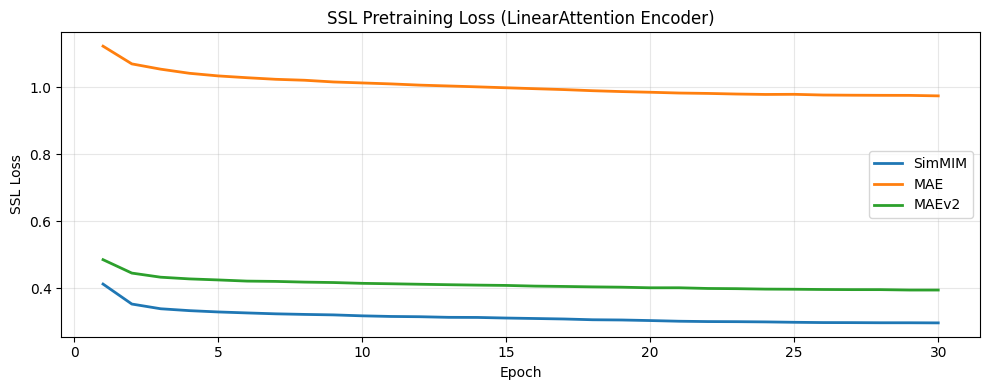

In [10]:

import gc
import time
from pathlib import Path
from contextlib import nullcontext
from tqdm import tqdm

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

try:
    from torch.amp import autocast as amp_autocast             
except Exception:
    amp_autocast = None

try:
    from torch.cuda.amp import GradScaler
except Exception:
    GradScaler = None


def get_autocast_context(device: torch.device, enabled: bool):
    if not enabled or device.type != "cuda":
        return nullcontext()

    if amp_autocast is not None:
        try:
            return amp_autocast(device_type="cuda", enabled=True)
        except TypeError:
            return amp_autocast(enabled=True)

    from torch.cuda.amp import autocast as cuda_autocast
    return cuda_autocast(enabled=True)


print("=" * 70)
print("Self-Supervised Pretraining (LinearAttention Encoder): SimMIM + MAE + MAEv2")
print("=" * 70)

if not UNLABELED_FILE.exists():
    raise FileNotFoundError(f"Unlabeled HDF5 file not found: {UNLABELED_FILE}")

pretrain_dataset_raw = LazyHDF5Dataset(
    UNLABELED_FILE,
    labeled=False,
    img_key="jet",
)

pretrain_dataset = TransformedDataset(pretrain_dataset_raw, ValTransform(IMG_SIZE, IN_CHANS))
pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

print(f"Pretraining samples: {len(pretrain_dataset)} | batches: {len(pretrain_loader)}")

PRETRAIN_EPOCHS = 30
print(f"Using PRETRAIN_EPOCHS={PRETRAIN_EPOCHS} for each SSL model", flush=True)

assert PRETRAIN_EPOCHS >= 10, (
    f"PRETRAIN_EPOCHS={PRETRAIN_EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and PRETRAIN_EPOCHS>=10."
)

SSL_PRETRAIN_CONFIGS = {
    "SimMIM": {
        "cls": SimMIMPretrainer,
        "kwargs": {"mask_ratio": 0.50},
        "ckpt": "linear_vit_pretrain_simmim_vit-5_chnges.pt",
        "plot_label": "SimMIM Loss",
    },
    "MAE": {
        "cls": MAEPretrainer,
        "kwargs": {"mask_ratio": 0.75},
        "ckpt": "linear_vit_pretrain_mae_vit-5_chnges.pt",
        "plot_label": "MAE Loss",
    },
    "MAEv2": {
        "cls": MAEv2Pretrainer,
        "kwargs": {"mask_ratio": 0.85, "block_masking": True},
        "ckpt": "linear_vit_pretrain_maev2_vit-5_chnges.pt",
        "plot_label": "MAEv2 Loss",
    },
}

CKPT_DIR = Path("../checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED_ENCODER_PATHS = {}
pretrained_encoder_states = {}
pretrain_losses_by_method = {}
pretrain_times = {}

for ssl_name, cfg in SSL_PRETRAIN_CONFIGS.items():
    print("\n" + "-" * 70)
    print(f"[FULL RUN] Pretraining {ssl_name} for {PRETRAIN_EPOCHS} epochs")
    print("-" * 70)

    seed_everything(SEED)
    pretrain_model = cfg["cls"](**cfg["kwargs"]).to(DEVICE)
    pretrain_params = sum(p.numel() for p in pretrain_model.parameters() if p.requires_grad)
    print(f"{ssl_name} parameters: {pretrain_params:,} ({pretrain_params/1e6:.2f}M)")

    pretrain_optimizer = torch.optim.AdamW(
        pretrain_model.parameters(),
        lr=LR_PRETRAIN,
        weight_decay=WEIGHT_DECAY,
    )
    pretrain_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        pretrain_optimizer,
        T_max=PRETRAIN_EPOCHS,
        eta_min=1e-6,
    )

    use_amp = USE_AMP and (DEVICE.type == "cuda")
    pretrain_scaler = GradScaler(enabled=use_amp) if GradScaler is not None else None

    pretrain_losses = []
    pretrain_start = time.time()

    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        pretrain_model.train()
        ep_loss = 0.0

        for batch in tqdm(pretrain_loader, desc=f"  {ssl_name} [{epoch}/{PRETRAIN_EPOCHS}]", leave=False):
            imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
            imgs = imgs.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))

            pretrain_optimizer.zero_grad(set_to_none=True)

            with get_autocast_context(DEVICE, enabled=use_amp):
                loss, _, _ = pretrain_model(imgs)

            if pretrain_scaler is not None:
                pretrain_scaler.scale(loss).backward()
                pretrain_scaler.unscale_(pretrain_optimizer)
                nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
                pretrain_scaler.step(pretrain_optimizer)
                pretrain_scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
                pretrain_optimizer.step()

            ep_loss += float(loss.item())

        ep_loss /= max(1, len(pretrain_loader))
        pretrain_losses.append(ep_loss)
        pretrain_scheduler.step()

        if epoch % 5 == 0 or epoch == PRETRAIN_EPOCHS:
            print(f"  Epoch {epoch:3d}/{PRETRAIN_EPOCHS} | loss={ep_loss:.4f}", flush=True)

    elapsed = time.time() - pretrain_start
    pretrain_times[ssl_name] = elapsed
    pretrain_losses_by_method[ssl_name] = pretrain_losses
    print(f"{ssl_name} pretraining complete in {elapsed:.1f}s", flush=True)

    encoder_state = pretrain_model.get_encoder_state_dict()
    save_path = (CKPT_DIR / cfg["ckpt"]).resolve()
    torch.save(encoder_state, save_path)

    PRETRAINED_ENCODER_PATHS[ssl_name] = str(save_path)
    pretrained_encoder_states[ssl_name] = encoder_state
    print(f"Saved {ssl_name} encoder -> {save_path}", flush=True)

    del pretrain_model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

PRETRAINED_ENCODER_PATH = PRETRAINED_ENCODER_PATHS["SimMIM"]
pretrained_encoder_state = pretrained_encoder_states["SimMIM"]

print("\nSaved pretrained encoder checkpoints:")
for n, p in PRETRAINED_ENCODER_PATHS.items():
    print(f"  {n}: {p}")

plt.figure(figsize=(10, 4))
for ssl_name, losses in pretrain_losses_by_method.items():
    plt.plot(range(1, len(losses) + 1), losses, linewidth=2, label=ssl_name)
plt.xlabel("Epoch")
plt.ylabel("SSL Loss")
plt.title("SSL Pretraining Loss (LinearAttention Encoder)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Section 10: Fine-tune Pretrained Linear Attention ViT Variants

> Requirement alignment: fine-tune **SimMIM-pretrained, MAE-pretrained, and MAEv2-pretrained** Linear Attention ViT models with low learning rate and compare against scratch and other baselines.

Loading pretrained encoder checkpoints:
  SimMIM: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_simmim_vit-5_chnges.pt
  MAE: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_mae_vit-5_chnges.pt
  MAEv2: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_maev2_vit-5_chnges.pt

[FULL RUN] Fine-tuning Linear Attention ViT (SimMIM-pretrained)

Experiment (UW-Loss): Linear Attention ViT (SimMIM-pretrained)
lr=3.000e-05, wd=0.0001, epochs=35
Loading pretrained encoder weights...
Loaded 110/110 block params.
Parameters: 8,244,355 (8.24M)
  [Phase A] Encoder frozen for epochs 1–7
[Epoch 1/35] start | lr=0.000e+00


[1/35]:   0%|                                                                                  | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 1/35] end | train_loss=1.0624 | val_loss=1.1477 | val_f1=0.3351 | val_acc=0.5040 | val_mae=43.8268 | lr=0.000e+00 | finite_steps=250/250 | nonfinite_steps=0
[Epoch 2/35] start | lr=1.000e-05


[2/35]:   0%|                                                                                  | 0/250 [00:00<…

...

[Epoch 35/35] end | train_loss=0.4149 | val_loss=0.4002 | val_f1=0.8730 | val_acc=0.8730 | val_mae=16.9943 | lr=1.070e-06 | finite_steps=250/250 | nonfinite_steps=0


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (SimMIM-pretrained) -- Best-F1 Checkpoint
  Classification:
    Accuracy       : 0.8740
    Balanced Acc.  : 0.8742
    F1 (macro)     : 0.8740
    Precision      : 0.8742
    Recall         : 0.8742
    ROC-AUC        : 0.9396
    PR-AUC         : 0.9234
    ECE            : 0.0337
  Regression:
    MSE            : 538.0564
    MAE            : 16.7014
    R²             : 0.8159


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (SimMIM-pretrained) -- Best-MAE Checkpoint
  Classification:
    Accuracy       : 0.8740
    Balanced Acc.  : 0.8742
    F1 (macro)     : 0.8740
    Precision      : 0.8742
    Recall         : 0.8742
    ROC-AUC        : 0.9396
    PR-AUC         : 0.9234
    ECE            : 0.0337
  Regression:
    MSE            : 538.0564
    MAE            : 16.7014
    R²             : 0.8159
Inference speed: 18.73 ms/sample
Training time: 2189.1s | Peak GPU: 1172 MB

Fine-tuning complete for SimMIM.


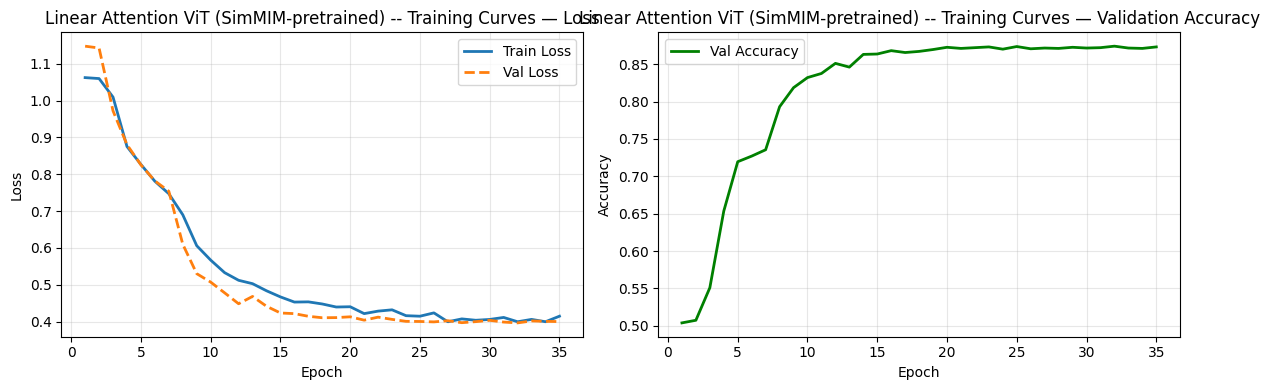

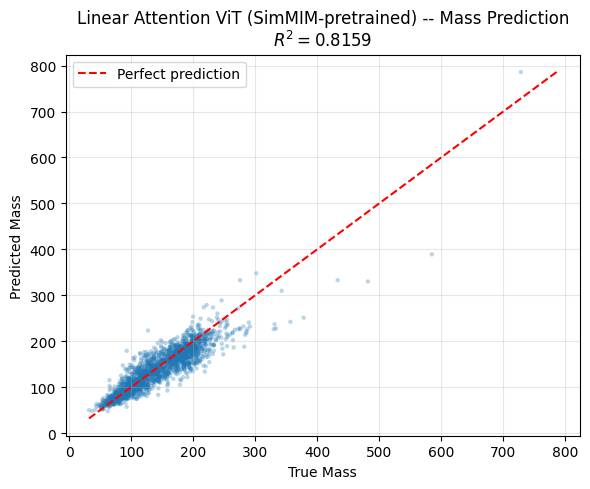

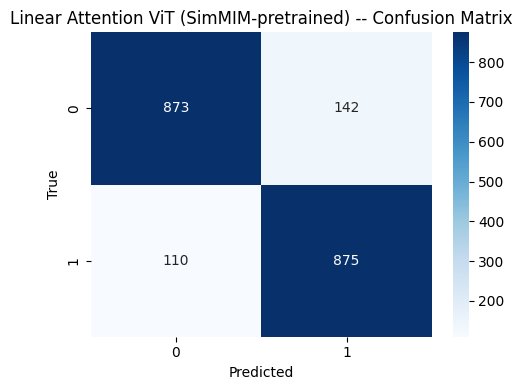


[FULL RUN] Fine-tuning Linear Attention ViT (MAE-pretrained)

Experiment (UW-Loss): Linear Attention ViT (MAE-pretrained)
lr=3.000e-05, wd=0.0001, epochs=35
Loading pretrained encoder weights...
Loaded 110/110 block params.
Parameters: 8,244,355 (8.24M)
  [Phase A] Encoder frozen for epochs 1–7
[Epoch 1/35] start | lr=0.000e+00


[1/35]:   0%|                                                                                  | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 1/35] end | train_loss=1.0632 | val_loss=1.1485 | val_f1=0.3300 | val_acc=0.4925 | val_mae=43.8242 | lr=0.000e+00 | finite_steps=250/250 | nonfinite_steps=0
[Epoch 2/35] start | lr=1.000e-05


[2/35]:   0%|                                                                                  | 0/250 [00:00<…

...

[Epoch 35/35] end | train_loss=0.3759 | val_loss=0.3541 | val_f1=0.8845 | val_acc=0.8845 | val_mae=14.9170 | lr=1.070e-06 | finite_steps=250/250 | nonfinite_steps=0


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (MAE-pretrained) -- Best-F1 Checkpoint
  Classification:
    Accuracy       : 0.8855
    Balanced Acc.  : 0.8858
    F1 (macro)     : 0.8855
    Precision      : 0.8862
    Recall         : 0.8858
    ROC-AUC        : 0.9501
    PR-AUC         : 0.9375
    ECE            : 0.0338
  Regression:
    MSE            : 437.5845
    MAE            : 14.9682
    R²             : 0.8503


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (MAE-pretrained) -- Best-MAE Checkpoint
  Classification:
    Accuracy       : 0.8845
    Balanced Acc.  : 0.8849
    F1 (macro)     : 0.8845
    Precision      : 0.8854
    Recall         : 0.8849
    ROC-AUC        : 0.9502
    PR-AUC         : 0.9376
    ECE            : 0.0321
  Regression:
    MSE            : 429.7220
    MAE            : 14.8667
    R²             : 0.8529
Inference speed: 16.80 ms/sample
Training time: 2184.1s | Peak GPU: 1238 MB

Fine-tuning complete for MAE.


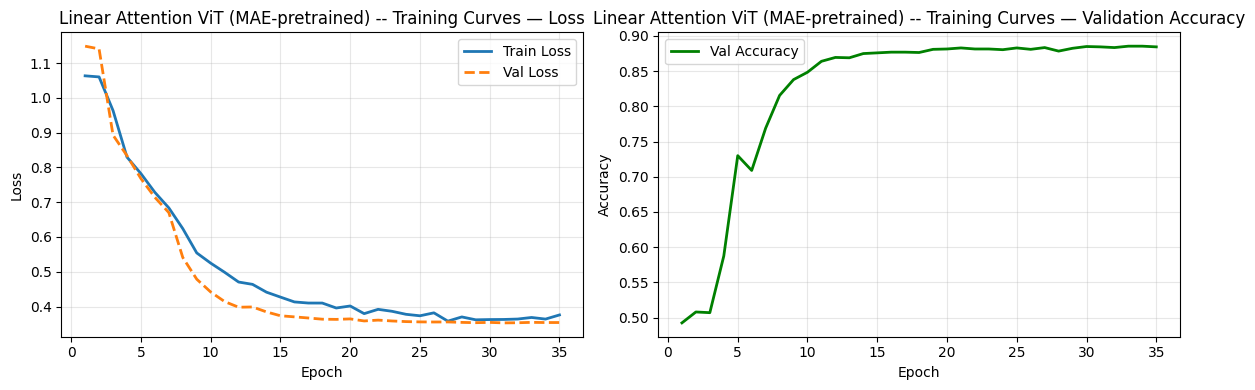

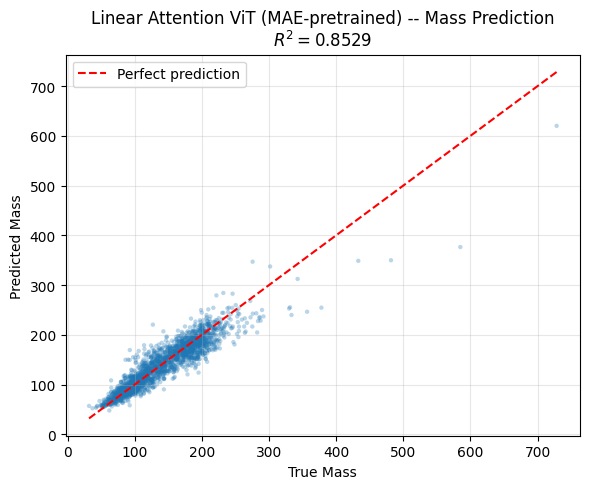

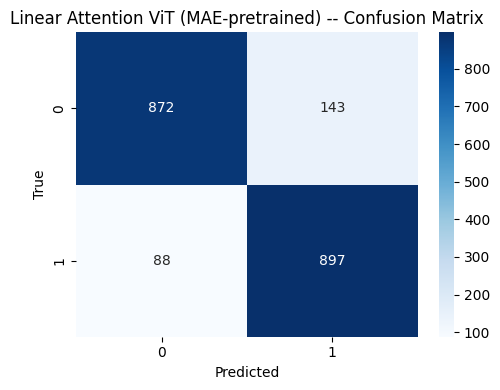


[FULL RUN] Fine-tuning Linear Attention ViT (MAEv2-pretrained)

Experiment (UW-Loss): Linear Attention ViT (MAEv2-pretrained)
lr=3.000e-05, wd=0.0001, epochs=35
Loading pretrained encoder weights...
Loaded 110/110 block params.
Parameters: 8,244,355 (8.24M)
  [Phase A] Encoder frozen for epochs 1–7
[Epoch 1/35] start | lr=0.000e+00


[1/35]:   0%|                                                                                  | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 1/35] end | train_loss=1.0622 | val_loss=1.1475 | val_f1=0.3367 | val_acc=0.5075 | val_mae=43.8275 | lr=0.000e+00 | finite_steps=250/250 | nonfinite_steps=0
[Epoch 2/35] start | lr=1.000e-05


[2/35]:   0%|                                                                                  | 0/250 [00:00<…

...

[Epoch 35/35] end | train_loss=0.4773 | val_loss=0.5009 | val_f1=0.8260 | val_acc=0.8260 | val_mae=19.8591 | lr=1.070e-06 | finite_steps=250/250 | nonfinite_steps=0


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (MAEv2-pretrained) -- Best-F1 Checkpoint
  Classification:
    Accuracy       : 0.8280
    Balanced Acc.  : 0.8280
    F1 (macro)     : 0.8280
    Precision      : 0.8280
    Recall         : 0.8280
    ROC-AUC        : 0.9078
    PR-AUC         : 0.8849
    ECE            : 0.0322
  Regression:
    MSE            : 750.1509
    MAE            : 19.8169
    R²             : 0.7433


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (MAEv2-pretrained) -- Best-MAE Checkpoint
  Classification:
    Accuracy       : 0.8245
    Balanced Acc.  : 0.8248
    F1 (macro)     : 0.8245
    Precision      : 0.8250
    Recall         : 0.8248
    ROC-AUC        : 0.9069
    PR-AUC         : 0.8836
    ECE            : 0.0311
  Regression:
    MSE            : 736.2875
    MAE            : 19.6364
    R²             : 0.7480
Inference speed: 16.28 ms/sample
Training time: 2183.5s | Peak GPU: 1304 MB

Fine-tuning complete for MAEv2.


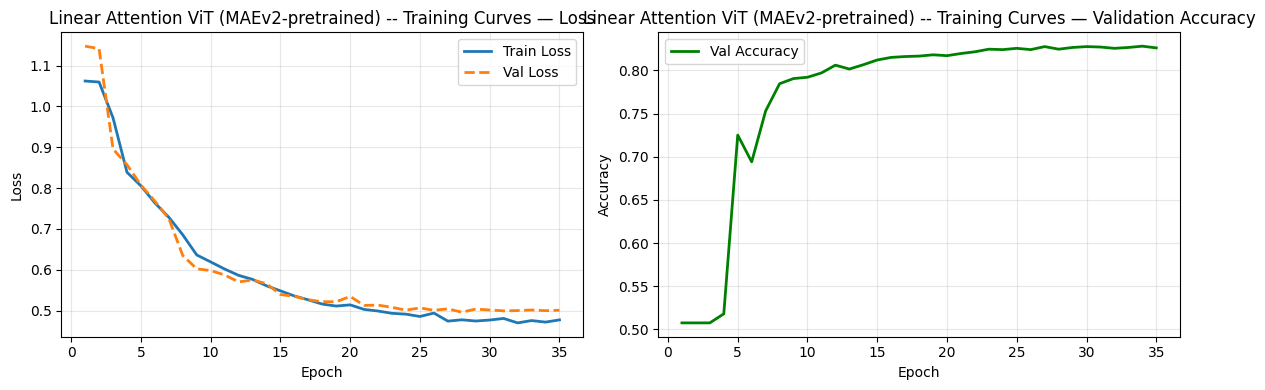

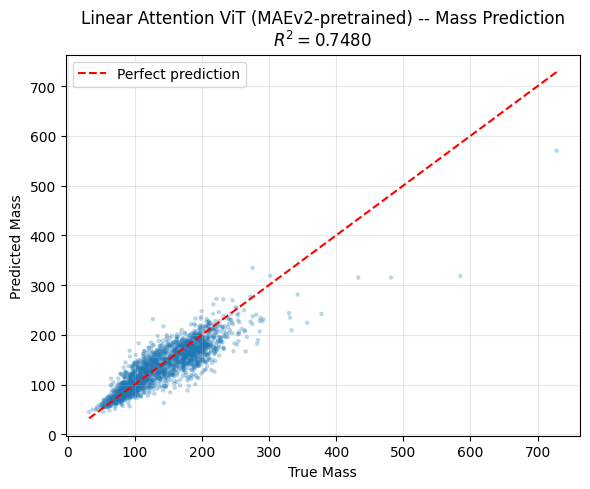

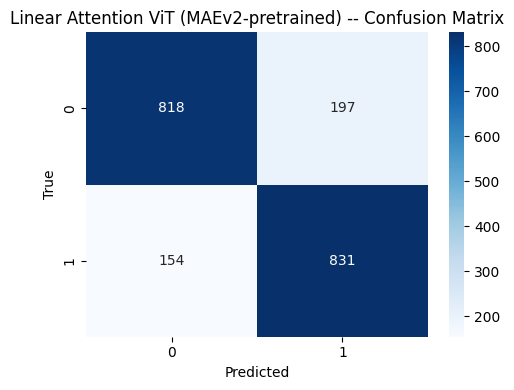

In [12]:

from pathlib import Path
from contextlib import nullcontext
import copy
import gc
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

PRINT_EPOCH_START = True
PRINT_EPOCH_END = True
EPOCH_STATUS_EVERY = 1                                        
SHOW_TQDM_BAR = True                                            
LOG_EVERY_N_BATCHES = 0                           

def log(msg):
    print(msg, flush=True)

try:
    from torch.amp import autocast as amp_autocast
except Exception:
    amp_autocast = None

try:
    from torch.cuda.amp import autocast as cuda_autocast
except Exception:
    cuda_autocast = None

def get_autocast_context(device, enabled=True):
    if (not enabled) or (device.type != "cuda"):
        return nullcontext()

    if amp_autocast is not None:
        try:
            return amp_autocast(device_type="cuda", enabled=True)
        except TypeError:
            try:
                return amp_autocast(enabled=True)
            except Exception:
                pass

    if cuda_autocast is not None:
        return cuda_autocast(enabled=True)

    return nullcontext()

def autocast(*args, **kwargs):
    enabled = bool(kwargs.get("enabled", True))
    return get_autocast_context(DEVICE, enabled=enabled)

@torch.no_grad()
def measure_inference_speed(model, input_shape=(1, IN_CHANS, IMG_SIZE, IMG_SIZE), n_runs=50):
    """Average inference time per sample in milliseconds."""
    model.eval()
    dummy = torch.randn(*input_shape, device=DEVICE)
    dummy_pt = torch.zeros(input_shape[0], device=DEVICE, dtype=dummy.dtype)

    def _forward_once(x):
        try:
            return model(x, dummy_pt)
        except TypeError:
            return model(x)

    for _ in range(5):
        _ = _forward_once(dummy)

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    for _ in range(n_runs):
        _ = _forward_once(dummy)

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = (time.time() - start) / n_runs * 1000
    return elapsed


def run_experiment_uw_quiet(
    model_class,
    model_name,
    train_loader,
    val_loader,
    pretrained_state=None,
    epochs=None,
    lr=None,
    weight_decay=None,
    patience=None,
    seed=None,
):
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    log(f"\n{'='*60}")
    log(f"Experiment (UW-Loss): {model_name}")
    log(f"lr={lr:.3e}, wd={weight_decay}, epochs={epochs}")
    log(f"{'='*60}")

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        log("Loading pretrained encoder weights...")
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])
            if "encoder_norm" in pretrained_state:
                model.norm.load_state_dict(pretrained_state["encoder_norm"])

            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]

            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v

            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            log(f"Loaded {len(matched)}/{len(model_blocks_sd)} block params.")
        except Exception as e:
            log(f"Warning: partial weight loading ({e}). Continuing.")

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    log(f"Parameters: {params:,} ({params/1e6:.2f}M)")

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )

    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(
        optimizer,
        warmup_epochs=warmup_epochs,
        total_epochs=epochs,
        eta_min=1e-6,
    )

    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")

    best_state     = None                                                        
    best_reg_state = None                                                       
    best_f1  = -1.0
    best_mae = float("inf")
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mse": [],
        "val_acc": [],
        "val_f1": [],
        "val_bal_acc": [],
        "lr": [],
    }

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        model.train()
        uw_loss.train()

        current_lr = optimizer.param_groups[0]["lr"]

        if TWO_PHASE_TRAINING:
            if epoch == 1:
                model.freeze_encoder()
                log(f"  [Phase A] Encoder frozen for epochs 1–{PHASE_A_EPOCHS}")
            elif epoch == PHASE_A_EPOCHS + 1:
                model.unfreeze_encoder()
                log(f"  [Phase B] Encoder unfrozen — full fine-tuning begins")

        total_loss = total_mse = total_ce = 0.0
        finite_steps = 0
        nonfinite_steps = 0
        first_nonfinite_reason = None

        if PRINT_EPOCH_START and (epoch % EPOCH_STATUS_EVERY == 0 or epoch == 1 or epoch == epochs):
            log(f"[Epoch {epoch}/{epochs}] start | lr={current_lr:.3e}")

        iterator = tqdm(
            train_loader,
            desc=f"[{epoch}/{epochs}]",
            leave=True,
            dynamic_ncols=True,
            disable=(not SHOW_TQDM_BAR),
        )

        for batch in iterator:
            imgs, masses, labels = batch[0], batch[1], batch[2]
            pt = batch[3].to(DEVICE) if len(batch) >= 4 else None
            imgs = imgs.to(DEVICE)
            masses = masses.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            r = np.random.rand()
            if r < 0.5:
                imgs, masses, la, lb, lam, pt = mixup_batch(imgs, masses, labels, alpha=0.4, pts=pt)
                use_mixed = True
            elif r < 0.8:
                imgs, masses, la, lb, lam, pt = physics_cutmix_batch(imgs, masses, labels, alpha=0.4, pts=pt)
                use_mixed = True
            else:
                la, lb, lam = labels, labels, 1.0
                use_mixed   = False

            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs, pt)
                masses_norm = masses                                              

                mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm) if USE_HUBER_LOSS\
                      else F.mse_loss(mass_pred.squeeze(1), masses_norm)

                ce = mixup_cross_entropy(class_logits, la, lb, lam) if use_mixed\
                     else F.cross_entropy(class_logits, labels)

                loss = uw_loss(ce, mse)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()

            total_loss += float(loss.item())
            total_mse += float(mse.item())
            total_ce += float(ce.item())
            finite_steps += 1

        if finite_steps == 0:
            log(
                f"[Epoch {epoch}/{epochs}] end | all steps non-finite; stopping "
                f"(nonfinite_steps={nonfinite_steps}, reason={first_nonfinite_reason})"
            )
            break

        train_stats = {
            "loss": total_loss / finite_steps,
            "mse": total_mse / finite_steps,
            "ce": total_ce / finite_steps,
        }

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)

        val_results["mass_pred"] = np.nan_to_num(val_results["mass_pred"], nan=0.0, posinf=1e6, neginf=-1e6)
        val_results["mass_true"] = np.nan_to_num(val_results["mass_true"], nan=0.0, posinf=1e6, neginf=-1e6)
        val_results["class_probs"] = np.nan_to_num(val_results["class_probs"], nan=0.0, posinf=1.0, neginf=0.0)

        row_sum = val_results["class_probs"].sum(axis=1, keepdims=True)
        row_sum = np.where(row_sum <= 0, 1.0, row_sum)
        val_results["class_probs"] = val_results["class_probs"] / row_sum

        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        if val_mae < best_mae:
            best_mae       = val_mae
            best_reg_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        if PRINT_EPOCH_END and (epoch % EPOCH_STATUS_EVERY == 0 or epoch == epochs):
            log(
                f"[Epoch {epoch}/{epochs}] end | "
                f"train_loss={train_stats['loss']:.4f} | "
                f"val_loss={val_results['loss']:.4f} | "
                f"val_f1={val_f1:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
                f"val_mae={val_mae:.4f} | lr={current_lr:.3e} | "
                f"finite_steps={finite_steps}/{len(train_loader)} | nonfinite_steps={nonfinite_steps}"
            )

        if early_stopper(val_f1):
            log(f"Early stop at epoch {epoch} (best F1={best_f1:.4f})")
            break

    train_time = time.time() - start_time
    peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6 if DEVICE.type == "cuda" else 0.0

    if best_state is not None:
        model.load_state_dict(best_state)

    cls_results = evaluate_model(model, val_loader)
    cls_results["mass_pred"] = np.nan_to_num(cls_results["mass_pred"], nan=0.0, posinf=1e6, neginf=-1e6)
    cls_results["mass_true"] = np.nan_to_num(cls_results["mass_true"], nan=0.0, posinf=1e6, neginf=-1e6)
    cls_results["class_probs"] = np.nan_to_num(cls_results["class_probs"], nan=0.0, posinf=1.0, neginf=0.0)

    cls_rs = cls_results["class_probs"].sum(axis=1, keepdims=True)
    cls_rs = np.where(cls_rs <= 0, 1.0, cls_rs)
    cls_results["class_probs"] = cls_results["class_probs"] / cls_rs

    cls_metrics = compute_metrics(cls_results)
    print_metrics(cls_metrics, f"{model_name} -- Best-F1 Checkpoint")

    if best_reg_state is not None:
        model.load_state_dict(best_reg_state)

    final_results = evaluate_model(model, val_loader)
    final_results["mass_pred"] = np.nan_to_num(final_results["mass_pred"], nan=0.0, posinf=1e6, neginf=-1e6)
    final_results["mass_true"] = np.nan_to_num(final_results["mass_true"], nan=0.0, posinf=1e6, neginf=-1e6)
    final_results["class_probs"] = np.nan_to_num(final_results["class_probs"], nan=0.0, posinf=1.0, neginf=0.0)

    rs = final_results["class_probs"].sum(axis=1, keepdims=True)
    rs = np.where(rs <= 0, 1.0, rs)
    final_results["class_probs"] = final_results["class_probs"] / rs

    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Best-MAE Checkpoint")

    inference_ms = measure_inference_speed(model)
    log(f"Inference speed: {inference_ms:.2f} ms/sample")
    log(f"Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB")

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name":       model_name,
        "model_state":      best_reg_state,                                 
        "cls_model_state":  best_state,                                         
        "history":          history,
        "final_metrics":    final_metrics,                                       
        "cls_metrics":      cls_metrics,                                             
        "final_results":    final_results,
        "cls_results":      cls_results,
        "train_time":       train_time,
        "params":           params,
        "peak_gpu_mem_mb":  peak_mem,
        "inference_ms":     inference_ms,
    }


if "PRETRAINED_ENCODER_PATHS" not in globals() or not PRETRAINED_ENCODER_PATHS:
    raise RuntimeError("PRETRAINED_ENCODER_PATHS not found. Run Section 9 first.")

log("Loading pretrained encoder checkpoints:")
for name, path in PRETRAINED_ENCODER_PATHS.items():
    log(f"  {name}: {path}")
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing checkpoint: {path}")

assert EPOCHS >= 10, f"EPOCHS={EPOCHS} too low; set RUN_MODE='full' and EPOCHS>=10."

FINETUNE_LR = LR * 0.1
result_linear_pretrained_all = {}

for ssl_name, ckpt_path in PRETRAINED_ENCODER_PATHS.items():
    log("\n" + "=" * 70)
    log(f"[FULL RUN] Fine-tuning Linear Attention ViT ({ssl_name}-pretrained)")
    log("=" * 70)

    try:
        pretrained_encoder_state = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    except TypeError:
        pretrained_encoder_state = torch.load(ckpt_path, map_location="cpu")

    result_linear_pretrained_all[ssl_name] = run_experiment_uw_quiet(
        model_class=LinearAttentionViT,
        model_name=f"Linear Attention ViT ({ssl_name}-pretrained)",
        train_loader=train_loader,
        val_loader=val_loader,
        pretrained_state=pretrained_encoder_state,
        epochs=EPOCHS,
        lr=FINETUNE_LR,
        weight_decay=WEIGHT_DECAY,
    )

    log(f"\nFine-tuning complete for {ssl_name}.")
    plot_training_curves(
        result_linear_pretrained_all[ssl_name]["history"],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Training Curves",
    )
    plot_mass_scatter(
        result_linear_pretrained_all[ssl_name]["final_results"]["mass_true"],
        result_linear_pretrained_all[ssl_name]["final_results"]["mass_pred"],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Mass Prediction",
    )
    plot_confusion_matrix(
        result_linear_pretrained_all[ssl_name]["final_metrics"]["confusion_matrix"],
        class_names=[str(i) for i in range(NUM_CLASSES)],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Confusion Matrix",
    )

result_linear_pretrained = result_linear_pretrained_all["SimMIM"]
PRETRAINED_ENCODER_PATH = PRETRAINED_ENCODER_PATHS["SimMIM"]

## Section 11: Train Linear Attention ViT from Scratch

> Requirement alignment: scratch baseline for direct comparison against pretrained linear attention model.

[FULL RUN] Training Linear Attention ViT (scratch) for 35 epochs

  Experiment (UW-Loss): Linear Attention ViT (scratch)_vit-5_chnges
  lr=0.0003, wd=0.0001, epochs=35
  Selection metric: val MAE (tie-break: val F1)
  Parameters: 8,244,355 (8.24M)
  [Phase A] Encoder frozen for epochs 1–7
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 1/35] end   | train_loss=1.0625 | val_loss=1.1481 | val_mae=43.8277 | val_f1=0.3367 | val_acc=0.5075
  [Epoch 2/35] start | lr=1.00e-04


  [2/35]:   0%|          | 0/250 [00:00<?, ?it/s]

...

  [Epoch 35/35] end   | train_loss=0.0772 | val_loss=0.4690 | val_mae=17.9107 | val_f1=0.8355 | val_acc=0.8365


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (scratch)_vit-5_chnges -- Best-F1 Checkpoint
  Classification:
    Accuracy       : 0.8415
    Balanced Acc.  : 0.8427
    F1 (macro)     : 0.8408
    Precision      : 0.8503
    Recall         : 0.8427
    ROC-AUC        : 0.9114
    PR-AUC         : 0.8813
    ECE            : 0.0317
  Regression:
    MSE            : 849.4347
    MAE            : 18.2566
    R²             : 0.7093


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (scratch)_vit-5_chnges -- Best-MAE Checkpoint
  Classification:
    Accuracy       : 0.8340
    Balanced Acc.  : 0.8354
    F1 (macro)     : 0.8328
    Precision      : 0.8467
    Recall         : 0.8354
    ROC-AUC        : 0.9132
    PR-AUC         : 0.8827
    ECE            : 0.0256
  Regression:
    MSE            : 824.1970
    MAE            : 17.8679
    R²             : 0.7180
  Inference speed: 18.03 ms/sample
  Training time: 2201.4s | Peak GPU: 1370 MB

Linear Attention ViT (scratch) training complete.


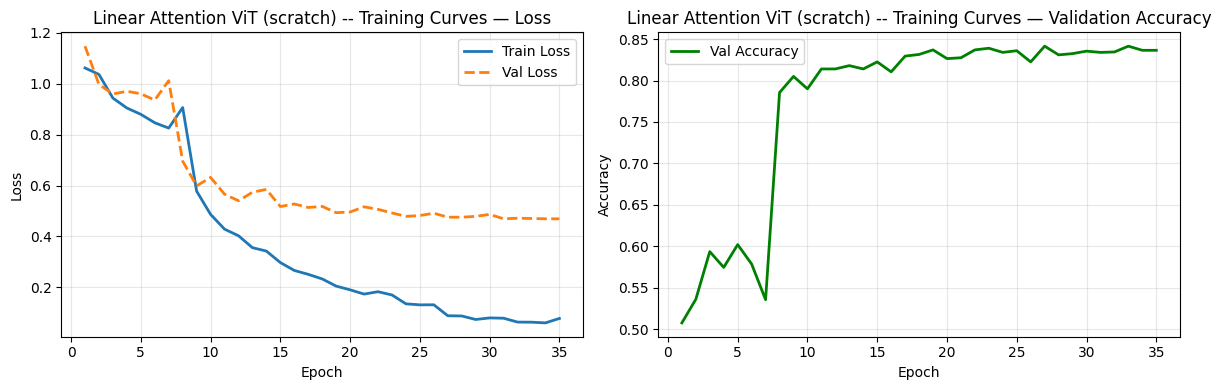

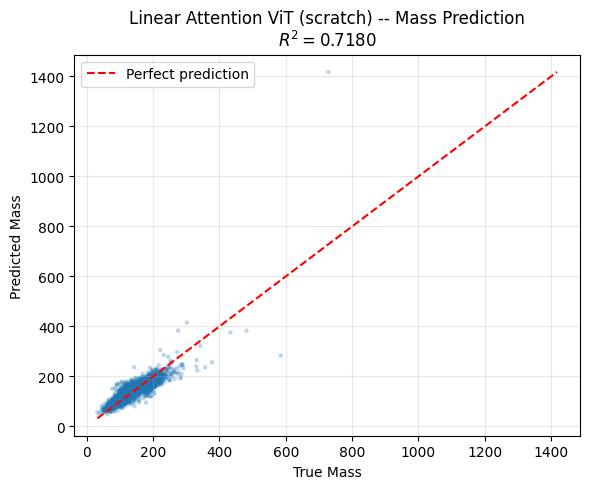

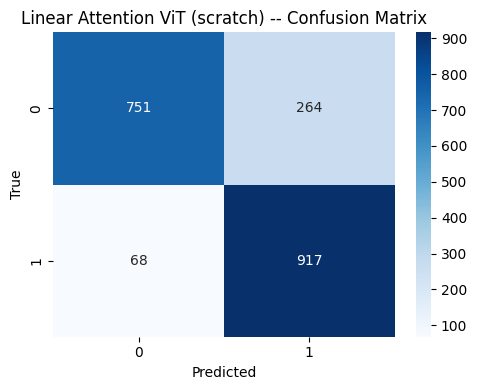

In [13]:

assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training Linear Attention ViT (scratch) for {EPOCHS} epochs", flush=True)

result_linear_scratch = run_experiment_uw(
    model_class=LinearAttentionViT,
    model_name="Linear Attention ViT (scratch)_vit-5_chnges",
    train_loader=train_loader,
    val_loader=val_loader,
    pretrained_state=None,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nLinear Attention ViT (scratch) training complete.")
plot_training_curves(result_linear_scratch["history"], title="Linear Attention ViT (scratch) -- Training Curves")
plot_mass_scatter(
    result_linear_scratch["final_results"]["mass_true"],
    result_linear_scratch["final_results"]["mass_pred"],
    title="Linear Attention ViT (scratch) -- Mass Prediction",
)
plot_confusion_matrix(
    result_linear_scratch["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="Linear Attention ViT (scratch) -- Confusion Matrix",
)

## Section 12 (Optional Baseline): Train Standard ViT

[FULL RUN] Training Standard ViT for 35 epochs

  Experiment (UW-Loss): Standard ViT
  lr=0.0003, wd=0.0001, epochs=35
  Selection metric: val MAE (tie-break: val F1)
  Parameters: 8,244,355 (8.24M)
  [Phase A] Encoder frozen for epochs 1–7
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 1/35] end   | train_loss=1.0614 | val_loss=1.1482 | val_mae=43.8276 | val_f1=0.3367 | val_acc=0.5075
  [Epoch 2/35] start | lr=1.00e-04


  [2/35]:   0%|          | 0/250 [00:00<?, ?it/s]

...

  [Epoch 35/35] end   | train_loss=-0.0560 | val_loss=0.4116 | val_mae=16.3743 | val_f1=0.8633 | val_acc=0.8635


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Standard ViT -- Best-F1 Checkpoint
  Classification:
    Accuracy       : 0.8650
    Balanced Acc.  : 0.8656
    F1 (macro)     : 0.8649
    Precision      : 0.8669
    Recall         : 0.8656
    ROC-AUC        : 0.9298
    PR-AUC         : 0.9097
    ECE            : 0.0224
  Regression:
    MSE            : 787.7703
    MAE            : 16.6842
    R²             : 0.7304


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Standard ViT -- Best-MAE Checkpoint
  Classification:
    Accuracy       : 0.8615
    Balanced Acc.  : 0.8624
    F1 (macro)     : 0.8612
    Precision      : 0.8668
    Recall         : 0.8624
    ROC-AUC        : 0.9310
    PR-AUC         : 0.9116
    ECE            : 0.0247
  Regression:
    MSE            : 703.2146
    MAE            : 16.2305
    R²             : 0.7594
  Inference speed: 14.28 ms/sample
  Training time: 2186.8s | Peak GPU: 1400 MB

Standard ViT training complete.


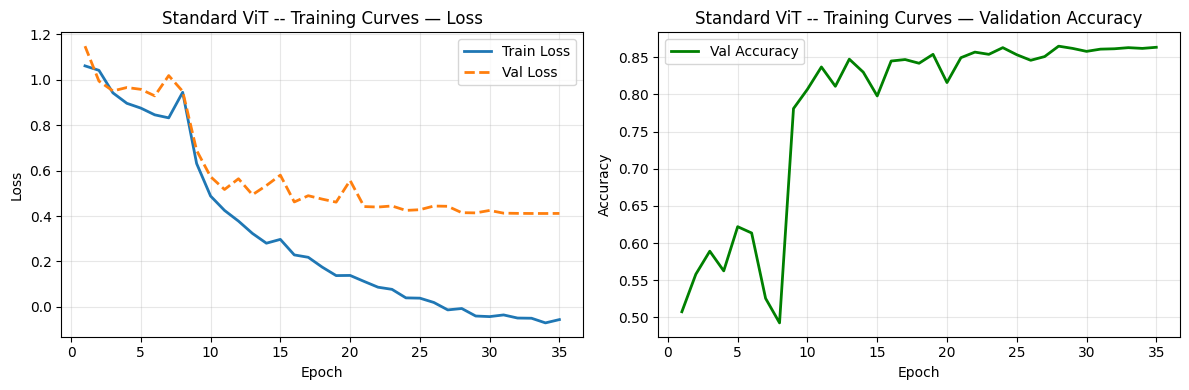

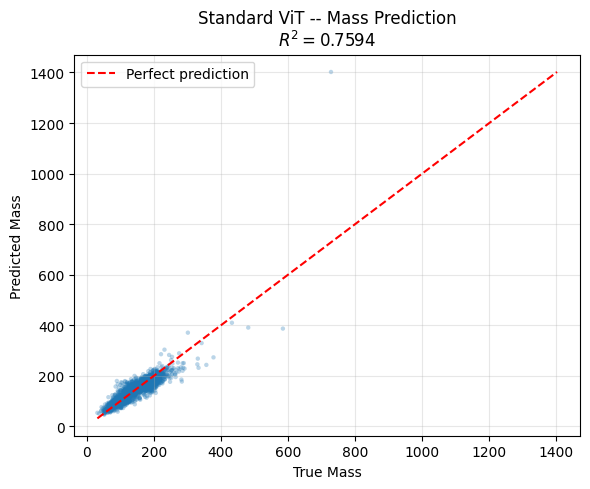

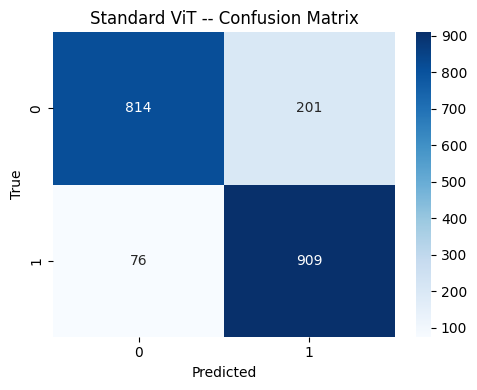

In [14]:

assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training Standard ViT for {EPOCHS} epochs", flush=True)

result_vit = run_experiment_uw(
    model_class=StandardViT,
    model_name="Standard ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nStandard ViT training complete.")
plot_training_curves(result_vit["history"], title="Standard ViT -- Training Curves")
plot_mass_scatter(
    result_vit["final_results"]["mass_true"],
    result_vit["final_results"]["mass_pred"],
    title="Standard ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_vit["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="Standard ViT -- Confusion Matrix",
)


## Section 13 (Optional Baseline): Train XCiT ViT from Scratch

[FULL RUN] Training XCiT ViT (scratch baseline) for 35 epochs

  Experiment (UW-Loss): XCiT ViT (scratch)
  lr=0.0003, wd=0.0001, epochs=35
  Selection metric: val MAE (tie-break: val F1)
  Parameters: 8,313,555 (8.31M)
  [Phase A] Encoder frozen for epochs 1–7
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 1/35] end   | train_loss=1.0583 | val_loss=1.1477 | val_mae=43.8292 | val_f1=0.3300 | val_acc=0.4925
  [Epoch 2/35] start | lr=1.00e-04


  [2/35]:   0%|          | 0/250 [00:00<?, ?it/s]

...

  [Epoch 24/35] end   | train_loss=-0.1618 | val_loss=0.5039 | val_mae=17.8363 | val_f1=0.8225 | val_acc=0.8235
  Early stop at epoch 24 (best MAE=17.6460)


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  XCiT ViT (scratch) -- Best-F1 Checkpoint
  Classification:
    Accuracy       : 0.8450
    Balanced Acc.  : 0.8449
    F1 (macro)     : 0.8449
    Precision      : 0.8450
    Recall         : 0.8449
    ROC-AUC        : 0.9131
    PR-AUC         : 0.8864
    ECE            : 0.0186
  Regression:
    MSE            : 721.2885
    MAE            : 18.2890
    R²             : 0.7532


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  XCiT ViT (scratch) -- Best-MAE Checkpoint
  Classification:
    Accuracy       : 0.8410
    Balanced Acc.  : 0.8413
    F1 (macro)     : 0.8410
    Precision      : 0.8416
    Recall         : 0.8413
    ROC-AUC        : 0.9143
    PR-AUC         : 0.8889
    ECE            : 0.0149
  Regression:
    MSE            : 641.4811
    MAE            : 17.6460
    R²             : 0.7805
  Inference speed: 23.68 ms/sample
  Training time: 1629.2s | Peak GPU: 1630 MB

XCiT ViT (scratch) training complete.


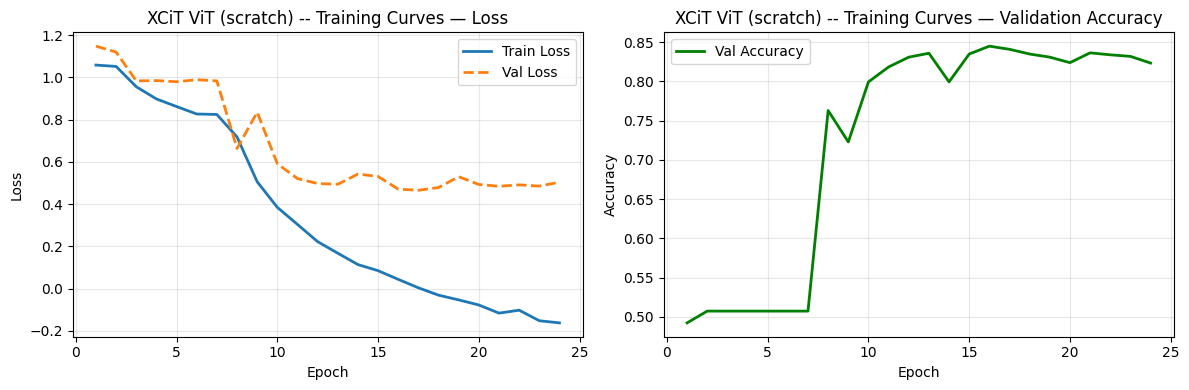

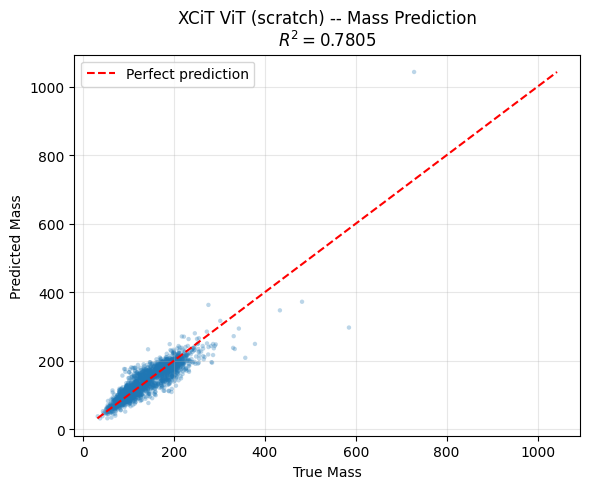

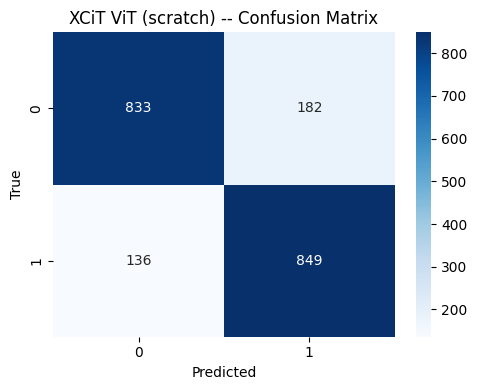

In [15]:

assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training XCiT ViT (scratch baseline) for {EPOCHS} epochs", flush=True)

result_xcit_scratch = run_experiment_uw(
    model_class=XCiTViT,
    model_name="XCiT ViT (scratch)",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nXCiT ViT (scratch) training complete.")
plot_training_curves(result_xcit_scratch["history"], title="XCiT ViT (scratch) -- Training Curves")
plot_mass_scatter(
    result_xcit_scratch["final_results"]["mass_true"],
    result_xcit_scratch["final_results"]["mass_pred"],
    title="XCiT ViT (scratch) -- Mass Prediction",
)
plot_confusion_matrix(
    result_xcit_scratch["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="XCiT ViT (scratch) -- Confusion Matrix",
)

## Section 14: Train L2ViT

[FULL RUN] Training L2ViT for 35 epochs

  Experiment (UW-Loss): L2ViT
  lr=0.0003, wd=0.0001, epochs=35
  Selection metric: val MAE (tie-break: val F1)
  Parameters: 8,403,080 (8.40M)
  [Phase A] Encoder frozen for epochs 1–7
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 2/35] end   | train_loss=1.0514 | val_loss=1.1250 | val_mae=42.6590 | val_f1=0.3554 | val_acc=0.5140
  [Epoch 3/35] start | lr=2.00e-04


  [3/35]:   0%|          | 0/250 [00:00<?, ?it/s]

...

  [Epoch 35/35] end   | train_loss=-0.5314 | val_loss=0.3582 | val_mae=12.0747 | val_f1=0.8690 | val_acc=0.8690


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  L2ViT -- Best-F1 Checkpoint
  Classification:
    Accuracy       : 0.8900
    Balanced Acc.  : 0.8906
    F1 (macro)     : 0.8899
    Precision      : 0.8924
    Recall         : 0.8906
    ROC-AUC        : 0.9472
    PR-AUC         : 0.9331
    ECE            : 0.0645
  Regression:
    MSE            : 496.2769
    MAE            : 14.4817
    R²             : 0.8302


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  L2ViT -- Best-MAE Checkpoint
  Classification:
    Accuracy       : 0.8695
    Balanced Acc.  : 0.8694
    F1 (macro)     : 0.8694
    Precision      : 0.8696
    Recall         : 0.8694
    ROC-AUC        : 0.9433
    PR-AUC         : 0.9303
    ECE            : 0.0381
  Regression:
    MSE            : 429.6759
    MAE            : 12.0620
    R²             : 0.8530
  Inference speed: 26.13 ms/sample
  Training time: 2369.6s | Peak GPU: 1561 MB

L2ViT training complete.


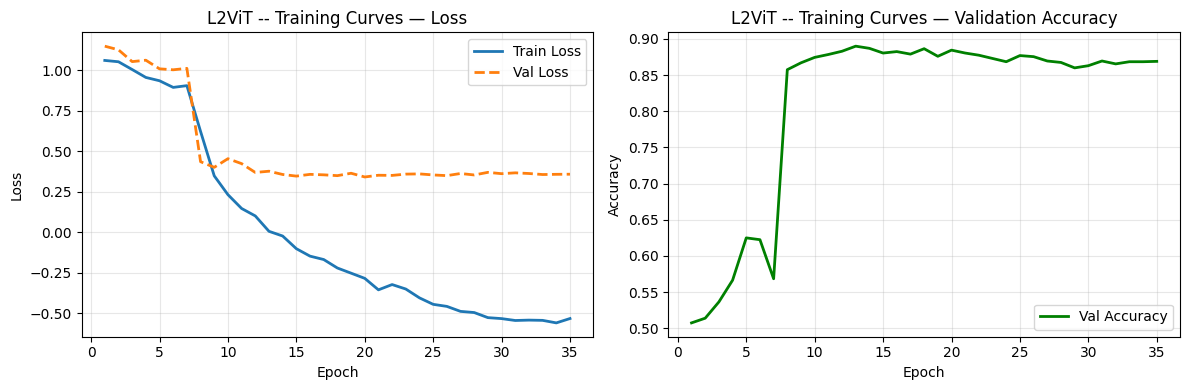

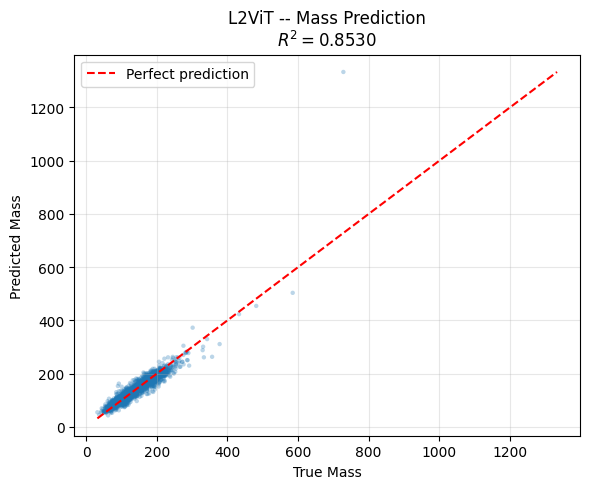

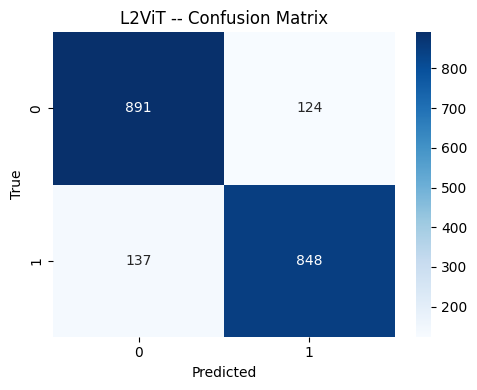

In [16]:

assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training L2ViT for {EPOCHS} epochs", flush=True)

result_l2vit = run_experiment_uw(
    model_class=L2ViT,
    model_name="L2ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nL2ViT training complete.")
plot_training_curves(result_l2vit["history"], title="L2ViT -- Training Curves")
plot_mass_scatter(
    result_l2vit["final_results"]["mass_true"],
    result_l2vit["final_results"]["mass_pred"],
    title="L2ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_l2vit["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="L2ViT -- Confusion Matrix",
)

## Section 15: Benchmark Comparison & Model Saving

Comprehensive comparison across all trained model variants plus model weight saving.


BENCHMARK COMPARISON
                                         Accuracy Bal. Acc.      F1 ROC-AUC  PR-AUC     ECE       MSE      MAE      R2 Train Time (s) Inference (ms) GPU Mem (MB) Parameters
Model                                                                                                                                                                       
Linear Attention ViT (SimMIM-pretrained)   0.8740    0.8742  0.8740  0.9396  0.9234  0.0337  538.0564  16.7014  0.8159         2189.1          18.73         1172  8,244,355
Linear Attention ViT (MAE-pretrained)      0.8845    0.8849  0.8845  0.9502  0.9376  0.0321  429.7220  14.8667  0.8529         2184.1          16.80         1238  8,244,355
Linear Attention ViT (MAEv2-pretrained)    0.8245    0.8248  0.8245  0.9069  0.8836  0.0311  736.2875  19.6364  0.7480         2183.5          16.28         1304  8,244,355
Linear Attention ViT (scratch)             0.8340    0.8354  0.8328  0.9132  0.8827  0.0256  824.1970  17.8679  0

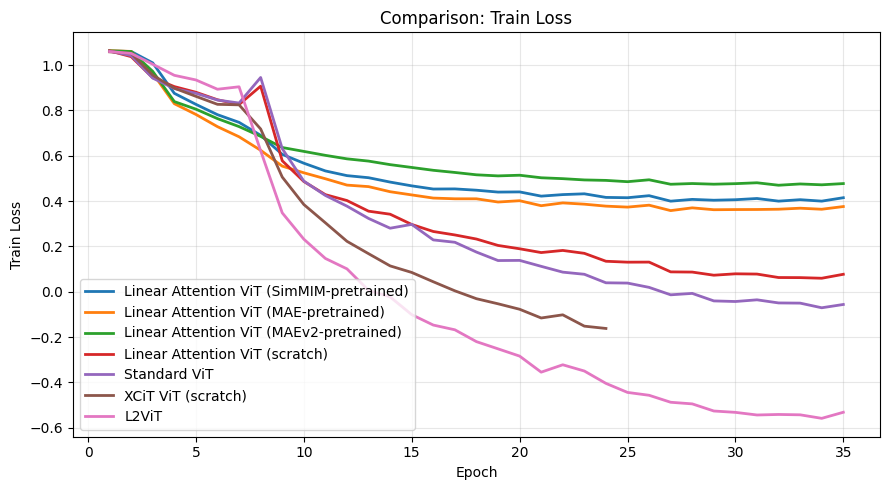

--- Comparison: Validation Accuracy ---


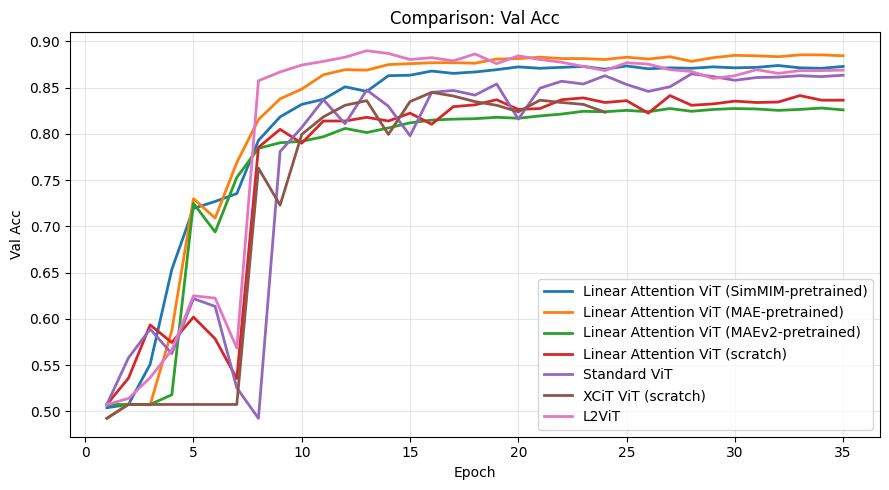

--- Mass Prediction Scatter Plots ---


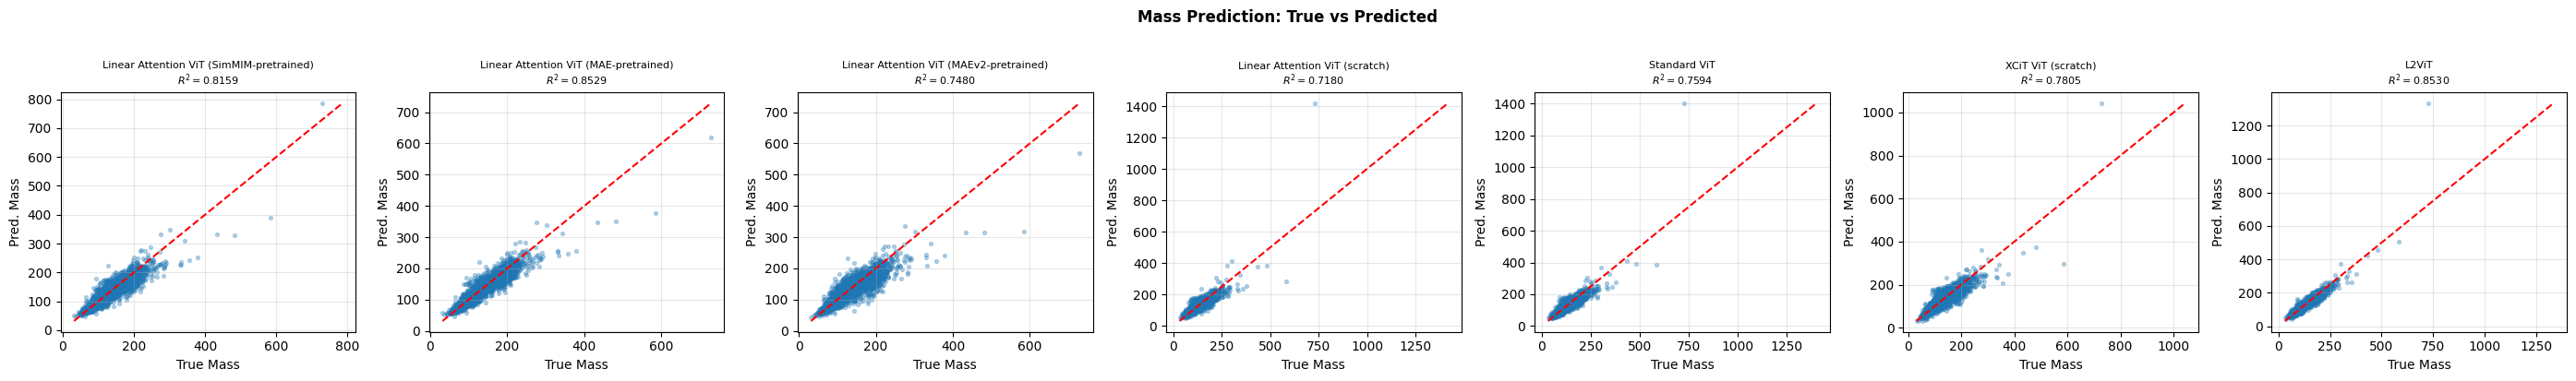

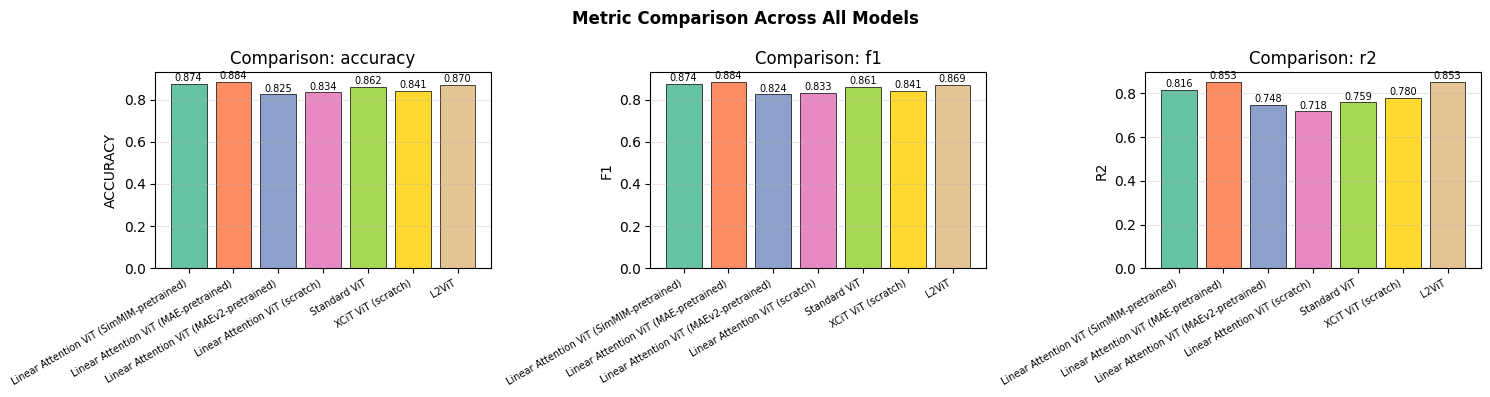

In [17]:

import os

all_results = {
    "Linear Attention ViT (SimMIM-pretrained)": result_linear_pretrained_all["SimMIM"],
    "Linear Attention ViT (MAE-pretrained)": result_linear_pretrained_all["MAE"],
    "Linear Attention ViT (MAEv2-pretrained)": result_linear_pretrained_all["MAEv2"],
    "Linear Attention ViT (scratch)": result_linear_scratch,
    "Standard ViT": result_vit,
    "XCiT ViT (scratch)": result_xcit_scratch,
    "L2ViT": result_l2vit,
}

rows = []
for name, res in all_results.items():
    m = res["final_metrics"]
    rows.append({
        "Model": name,
        "Accuracy": f"{m['accuracy']:.4f}",
        "Bal. Acc.": f"{m.get('balanced_accuracy', 0):.4f}",
        "F1": f"{m['f1']:.4f}",
        "ROC-AUC": f"{m.get('roc_auc', 0):.4f}",
        "PR-AUC": f"{m.get('pr_auc', 0):.4f}",
        "ECE": f"{m.get('ece', 0):.4f}",
        "MSE": f"{m['mse']:.4f}",
        "MAE": f"{m['mae']:.4f}",
        "R2": f"{m['r2']:.4f}",
        "Train Time (s)": f"{res['train_time']:.1f}",
        "Inference (ms)": f"{res['inference_ms']:.2f}",
        "GPU Mem (MB)": f"{res.get('peak_gpu_mem_mb', 0):.0f}",
        "Parameters": f"{res['params']:,}",
    })

df = pd.DataFrame(rows).set_index("Model")
print("\n" + "=" * 140, flush=True)
print("BENCHMARK COMPARISON", flush=True)
print("=" * 140, flush=True)
print(df.to_string(), flush=True)
print("=" * 140, flush=True)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)
df.to_csv(results_dir / "final_benchmark_results.csv")
print(f"Results saved to {results_dir / 'final_benchmark_results.csv'}", flush=True)


models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

model_save_map = {
    "Linear Attention ViT (SimMIM-pretrained)": "linear_vit_simmim_pretrained_vit-5_chnges.pt",
    "Linear Attention ViT (MAE-pretrained)": "linear_vit_mae_pretrained_vit-5_chnges.pt",
    "Linear Attention ViT (MAEv2-pretrained)": "linear_vit_maev2_pretrained_vit-5_chnges.pt",
    "Linear Attention ViT (scratch)": "linear_vit_scratch_vit-5_chnges.pt",
    "Standard ViT": "vit_vit-5_chnges.pt",
    "XCiT ViT (scratch)": "xcit_scratch_vit-5_chnges.pt",
    "L2ViT": "l2vit_vit-5_chnges.pt",
}

for name, filename in model_save_map.items():
    if name in all_results and "model_state" in all_results[name]:
        save_path = models_dir / filename
        torch.save(all_results[name]["model_state"], save_path)
        print(f"Saved {name} -> {save_path}", flush=True)

if "PRETRAINED_ENCODER_PATHS" in globals() and PRETRAINED_ENCODER_PATHS:
    import shutil
    for ssl_name, src_path in PRETRAINED_ENCODER_PATHS.items():
        if os.path.exists(src_path):
            encoder_path = models_dir / f"pretrained_encoder_{ssl_name.lower()}.pt"
            shutil.copy2(src_path, encoder_path)
            print(f"Saved pretrained encoder ({ssl_name}) -> {encoder_path}", flush=True)

print(f"\nAll model weights saved to {models_dir}/", flush=True)

print("\n--- Comparison: Training Loss ---", flush=True)
plot_comparison_curves(
    {name: res["history"] for name, res in all_results.items()},
    metric_name="train_loss",
)
print("--- Comparison: Validation Accuracy ---", flush=True)
plot_comparison_curves(
    {name: res["history"] for name, res in all_results.items()},
    metric_name="val_acc",
)

print("--- Mass Prediction Scatter Plots ---", flush=True)
n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, all_results.items()):
    fr = res["final_results"]
    r2 = res["final_metrics"]["r2"]
    ax.scatter(fr["mass_true"], fr["mass_pred"], alpha=0.3, s=8)
    lims = [
        min(fr["mass_true"].min(), fr["mass_pred"].min()),
        max(fr["mass_true"].max(), fr["mass_pred"].max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5)
    ax.set_xlabel("True Mass")
    ax.set_ylabel("Pred. Mass")
    ax.set_title(f"{name}\n$R^2={r2:.4f}$", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Mass Prediction: True vs Predicted", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

metric_keys = ["accuracy", "f1", "r2"]
fig, axes = plt.subplots(1, len(metric_keys), figsize=(5 * len(metric_keys), 4))
model_names = list(all_results.keys())
for ax, mk in zip(axes, metric_keys):
    vals = [all_results[n]["final_metrics"][mk] for n in model_names]
    colors = plt.cm.Set2(range(len(model_names)))
    bars = ax.bar(range(len(model_names)), vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=7)
    ax.set_ylabel(mk.upper())
    ax.set_title(f"Comparison: {mk}")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
plt.suptitle("Metric Comparison Across All Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path
import os
import shutil

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

if "PRETRAINED_ENCODER_PATHS" in globals() and PRETRAINED_ENCODER_PATHS:
    aligned_names = {
        "SimMIM": "linear_vit_pretrain_simmim_vit-5_chnges.pt",
        "MAE": "linear_vit_pretrain_mae_vit-5_chnges.pt",
        "MAEv2": "linear_vit_pretrain_maev2_vit-5_chnges.pt",
    }
    for ssl_name, src_path in PRETRAINED_ENCODER_PATHS.items():
        if os.path.exists(src_path):
            aligned_encoder_path = models_dir / aligned_names.get(ssl_name, f"linear_vit_pretrain_{ssl_name.lower()}.pt")
            shutil.copy2(src_path, aligned_encoder_path)
            print(f"Saved requirement-aligned pretrained encoder ({ssl_name}) -> {aligned_encoder_path}", flush=True)

if "PRETRAINED_ENCODER_PATH" in globals() and os.path.exists(PRETRAINED_ENCODER_PATH):
    legacy_path = models_dir / "linear_vit_pretrain.pt"
    shutil.copy2(PRETRAINED_ENCODER_PATH, legacy_path)
    print(f"Saved legacy pretrained encoder alias -> {legacy_path}", flush=True)

Saved requirement-aligned pretrained encoder (SimMIM) -> ..\models\linear_vit_pretrain_simmim_vit-5_chnges.pt
Saved requirement-aligned pretrained encoder (MAE) -> ..\models\linear_vit_pretrain_mae_vit-5_chnges.pt
Saved requirement-aligned pretrained encoder (MAEv2) -> ..\models\linear_vit_pretrain_maev2_vit-5_chnges.pt
Saved legacy pretrained encoder alias -> ..\models\linear_vit_pretrain.pt


## Section 16: Final Results & Analysis

In [19]:

print("\n" + "=" * 140, flush=True)
print("FINAL BENCHMARK RESULTS -- PARTICLE COLLISION IMAGE ANALYSIS", flush=True)
print("=" * 140, flush=True)
print(df.to_string(), flush=True)
print("=" * 140, flush=True)

best_acc = max(all_results, key=lambda n: all_results[n]["final_metrics"]["accuracy"])
best_r2 = max(all_results, key=lambda n: all_results[n]["final_metrics"]["r2"])
best_f1 = max(all_results, key=lambda n: all_results[n]["final_metrics"]["f1"])
fastest = min(all_results, key=lambda n: all_results[n]["train_time"])
smallest = min(all_results, key=lambda n: all_results[n]["params"])
best_mse = min(all_results, key=lambda n: all_results[n]["final_metrics"]["mse"])
best_bal_acc = max(all_results, key=lambda n: all_results[n]["final_metrics"].get("balanced_accuracy", 0))

print(f"\n  Best Classification Accuracy : {best_acc}", flush=True)
print(f"  Best Balanced Accuracy       : {best_bal_acc}", flush=True)
print(f"  Best F1 Score                : {best_f1}", flush=True)
print(f"  Best Regression R2           : {best_r2}", flush=True)
print(f"  Lowest MSE                   : {best_mse}", flush=True)
print(f"  Fastest Training             : {fastest}", flush=True)
print(f"  Smallest Model               : {smallest}", flush=True)

ssl_variants = ["SimMIM", "MAE", "MAEv2"]
scratch_acc = result_linear_scratch["final_metrics"]["accuracy"]
scratch_r2 = result_linear_scratch["final_metrics"]["r2"]

print("\n  Pretraining benefit vs scratch (Linear ViT):", flush=True)
for ssl_name in ssl_variants:
    k = f"Linear Attention ViT ({ssl_name}-pretrained)"
    pt_acc = all_results[k]["final_metrics"]["accuracy"]
    pt_r2 = all_results[k]["final_metrics"]["r2"]
    print(f"    {ssl_name:6s} | ΔAcc={pt_acc - scratch_acc:+.4f} | ΔR2={pt_r2 - scratch_r2:+.4f}", flush=True)

best_ssl = max(
    ssl_variants,
    key=lambda n: all_results[f"Linear Attention ViT ({n}-pretrained)"]["final_metrics"]["f1"],
)
print(f"\n  Best SSL pretraining method by F1: {best_ssl}", flush=True)

result_linear_pretrained = result_linear_pretrained_all["SimMIM"]

print("\n--- Model Weight Loading Demo ---", flush=True)
models_dir = Path("../models")
for name, filename in model_save_map.items():
    fpath = models_dir / filename
    if fpath.exists():
        try:
            state = torch.load(fpath, map_location="cpu", weights_only=True)
        except TypeError:
            state = torch.load(fpath, map_location="cpu")
        print(f"  Loaded {filename}: {len(state)} parameter tensors", flush=True)

print("\n" + "=" * 140, flush=True)
print("Summary Complete -- See full comparison table above.", flush=True)
print("=" * 140, flush=True)


FINAL BENCHMARK RESULTS -- PARTICLE COLLISION IMAGE ANALYSIS
                                         Accuracy Bal. Acc.      F1 ROC-AUC  PR-AUC     ECE       MSE      MAE      R2 Train Time (s) Inference (ms) GPU Mem (MB) Parameters
Model                                                                                                                                                                       
Linear Attention ViT (SimMIM-pretrained)   0.8740    0.8742  0.8740  0.9396  0.9234  0.0337  538.0564  16.7014  0.8159         2189.1          18.73         1172  8,244,355
Linear Attention ViT (MAE-pretrained)      0.8845    0.8849  0.8845  0.9502  0.9376  0.0321  429.7220  14.8667  0.8529         2184.1          16.80         1238  8,244,355
Linear Attention ViT (MAEv2-pretrained)    0.8245    0.8248  0.8245  0.9069  0.8836  0.0311  736.2875  19.6364  0.7480         2183.5          16.28         1304  8,244,355
Linear Attention ViT (scratch)             0.8340    0.8354  0.8328  0.91

## Analysis & Discussion

### Attention Mechanism Comparison

| Architecture | Attention | Complexity | Key Feature |
|---|---|---|---|
| Standard ViT | Softmax(QK^T/sqrt(d))V | O(N^2*d) | Baseline |
| Linear Attention ViT | phi(Q)(phi(K)^T V) | O(N*d^2) | ReLU kernel maps |
| L2ViT | LWA + LGA | O(N*d^2) + O(w^2*d) | Hybrid local+global |
| XCiT ViT | Q^T K (channel) | O(N*d^2) | Cross-covariance |

### Physics-Informed Design Choices

- **Preprocessing**: Log energy compression, noise suppression, energy centroid alignment, event normalization, and per-channel standardization
- **Augmentation**: Detector-safe transforms only (horizontal flip, Gaussian noise, energy scaling, patch masking)
- **Mass Handling**: Dataset returns normalized mass targets; training/evaluation patch prevents double normalization and reports denormalized regression metrics
- **Deeper Regression Head**: 3-layer MLP captures complex mass-feature relationships

### Self-Supervised Pretraining (Requirement-Aligned)

Self-supervised pretraining is applied on a **LinearAttention encoder** using **SimMIM, MAE, and MAEv2** on unlabeled detector data.
The pretrained-vs-scratch gap for **Linear Attention ViT** quantifies the benefit of unlabeled pretraining under the task requirement.

### Multi-Task Learning

Uncertainty-weighted loss (Kendall et al., 2018) automatically balances classification and regression.

In [21]:

from pathlib import Path
import hashlib

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

root = Path.cwd().resolve()
target_dirs = [(root / "../models").resolve(), (root / "../checkpoints").resolve()]
target_dirs = [d for d in target_dirs if d.exists()]

if not target_dirs:
    print("No target folders found: ../models or ../checkpoints")
else:
    preferred_keep = {
        (root / "../models/linear_vit_simmim_pretrained_vit-5_chnges.pt").resolve(),
        (root / "../models/linear_vit_mae_pretrained_vit-5_chnges.pt").resolve(),
        (root / "../models/linear_vit_maev2_pretrained_vit-5_chnges.pt").resolve(),
        (root / "../models/linear_vit_scratch_vit-5_chnges.pt").resolve(),
        (root / "../models/vit_vit-5_chnges.pt").resolve(),
        (root / "../models/xcit_scratch_vit-5_chnges.pt").resolve(),
        (root / "../models/l2vit_vit-5_chnges.pt").resolve(),
        (root / "../checkpoints/linear_vit_pretrain_simmim_vit-5_chnges.pt").resolve(),
        (root / "../checkpoints/linear_vit_pretrain_mae_vit-5_chnges.pt").resolve(),
        (root / "../checkpoints/linear_vit_pretrain_maev2_vit-5_chnges.pt").resolve(),
    }

    pt_files = []
    for d in target_dirs:
        pt_files.extend(sorted(p.resolve() for p in d.glob("*.pt")))

    if not pt_files:
        print("No .pt files found.")
    else:
        by_hash = {}
        for p in pt_files:
            try:
                digest = sha256_file(p)
                by_hash.setdefault(digest, []).append(p)
            except Exception as e:
                print(f"[WARN] Could not hash {p}: {e}")

        to_delete = []
        kept = []

        for _, files in by_hash.items():
            if len(files) == 1:
                kept.append(files[0])
                continue

            keeper = next((f for f in files if f in preferred_keep), None)
            if keeper is None:
                keeper = sorted(files, key=lambda x: (len(str(x)), str(x)))[0]

            kept.append(keeper)
            to_delete.extend([f for f in files if f != keeper])

        deleted = 0
        for p in to_delete:
            try:
                p.unlink()
                deleted += 1
            except Exception as e:
                print(f"[WARN] Failed to delete {p}: {e}")

        print("\n=== Duplicate Weight Cleanup Done ===")
        print(f"Folders scanned: {[str(d) for d in target_dirs]}")
        print(f"Total .pt files scanned: {len(pt_files)}")
        print(f"Unique weight files kept: {len(by_hash)}")
        print(f"Duplicate files deleted: {deleted}")

        if deleted > 0:
            print("\nDeleted files:")
            for p in sorted(to_delete):
                print(" -", p)


=== Duplicate Weight Cleanup Done ===
Folders scanned: ["C:\\Users\\Rahul\\Desktop\\AA Gsoc'26\\models", "C:\\Users\\Rahul\\Desktop\\AA Gsoc'26\\checkpoints"]
Total .pt files scanned: 10
Unique weight files kept: 10
Duplicate files deleted: 0
